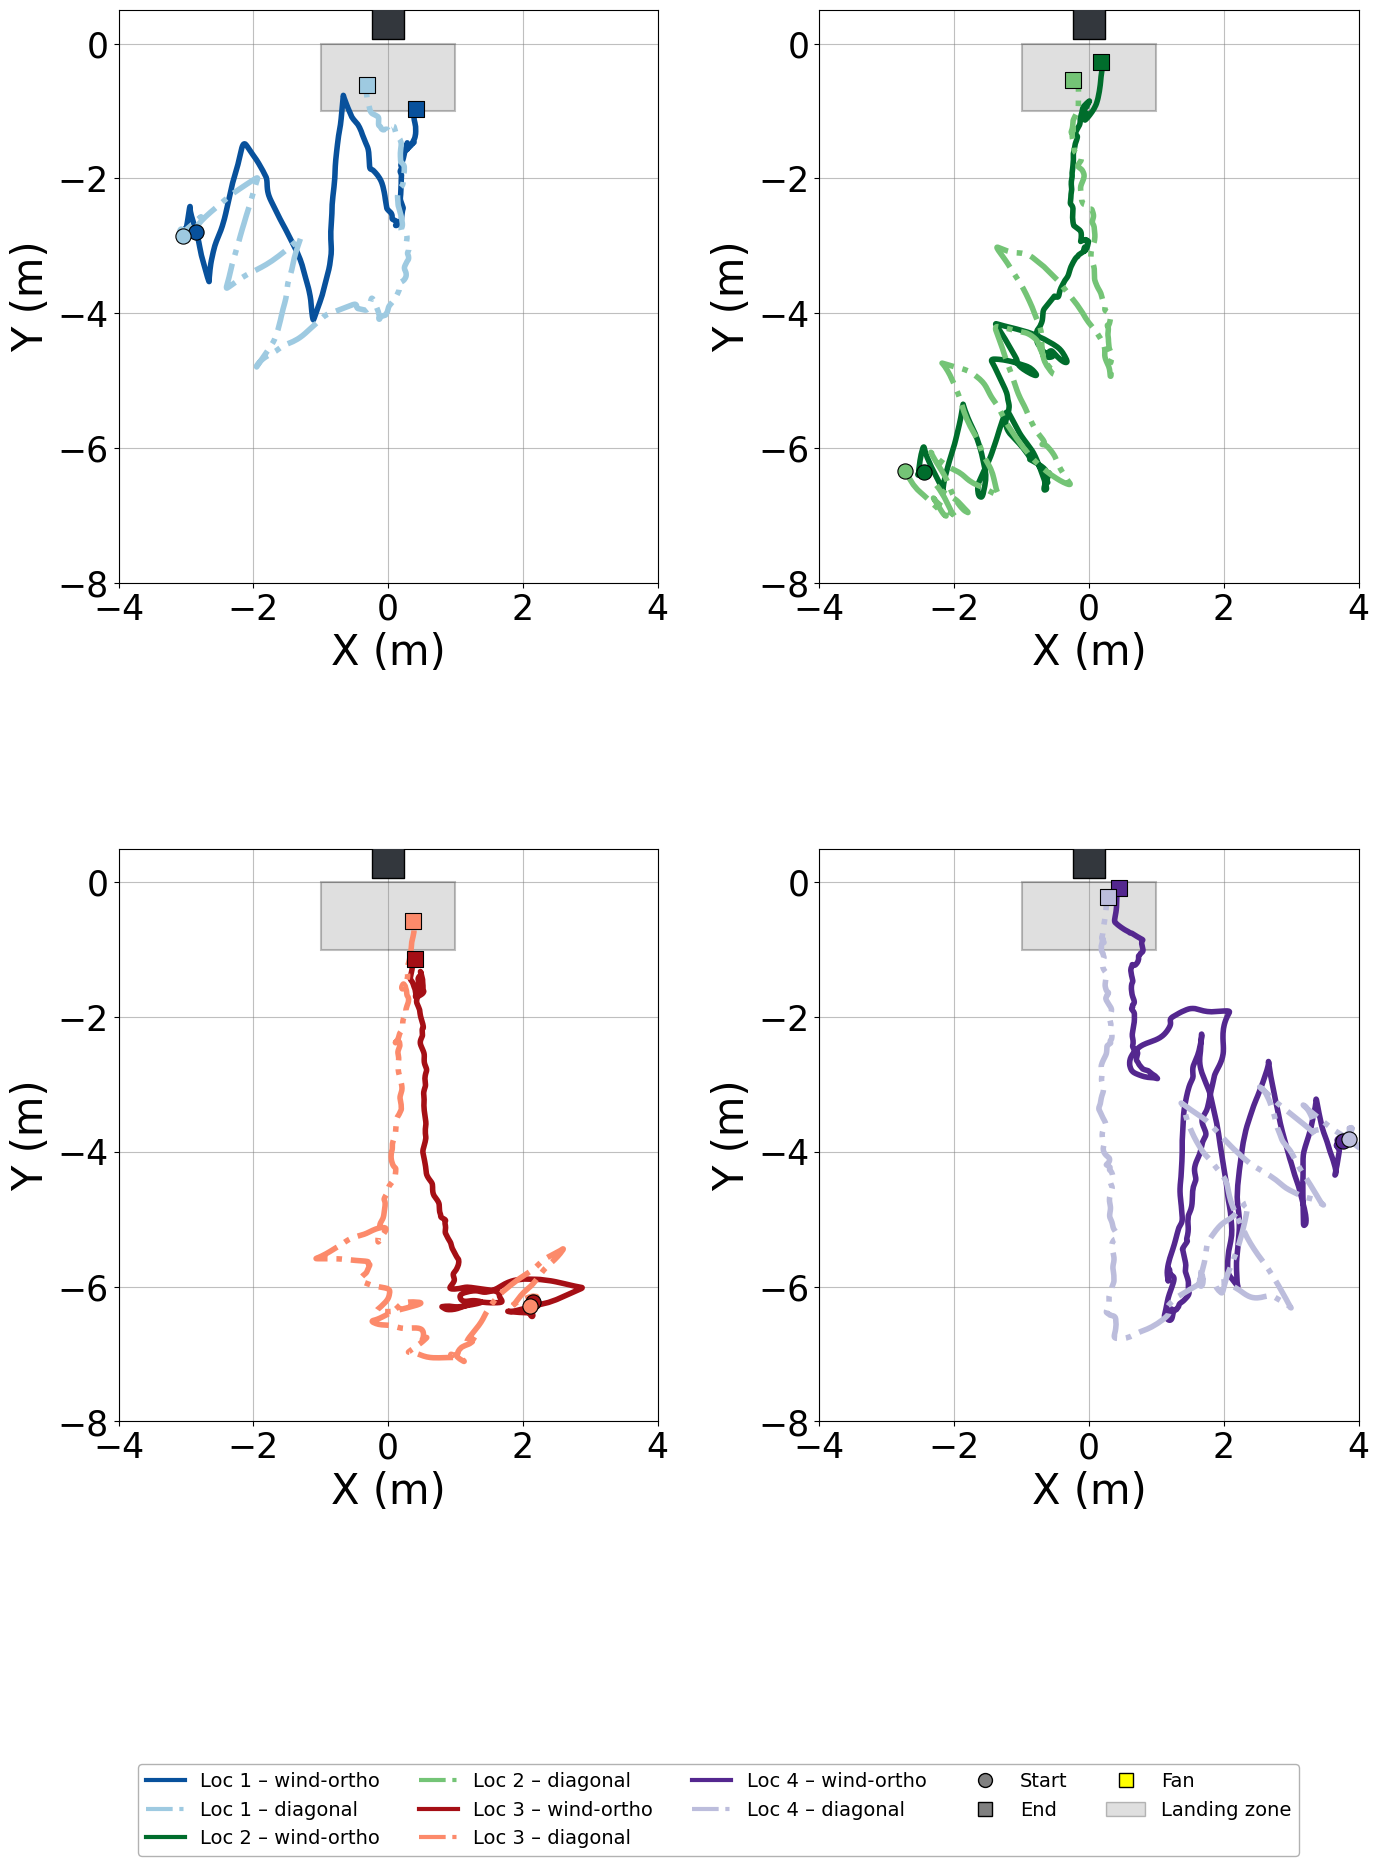

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
import re

plt.style.use('default')

# ── Trajectory (OptiTrack) files ──────────────────────────────────────────────
TRAJECTORY_FILES = r"""
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc1_Down.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc1_Ortho_2_perfect.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc2_Ortho_4.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc2_UpRedo_run3.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc3_Ortho_2.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc3_Up.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc4_Ortho.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc4_Down.csv
"""

# ── Constants ─────────────────────────────────────────────────────────────────
FAN_X_RAW = -1514.199707 / 1000
FAN_Y_RAW =  2919.908203 / 1000

# Per-location: main (ortho) color and lighter (non-ortho/diagonal) color
LOC_PALETTES = {
    'Loc1': {'ortho': '#08519c', 'non_ortho': '#9ecae1'},   # dark blue / light blue
    'Loc2': {'ortho': '#006d2c', 'non_ortho': '#74c476'},   # dark green / light green
    'Loc3': {'ortho': '#a50f15', 'non_ortho': '#fc8a6b'},   # dark red / light red-orange
    'Loc4': {'ortho': '#54278f', 'non_ortho': '#bcbddc'},   # dark purple / light purple
}

LOC_TITLES = {
    'Loc1': 'Location 1',
    'Loc2': 'Location 2',
    'Loc3': 'Location 3',
    'Loc4': 'Location 4',
}

FONT_TRAJ = 30
TICK_TRAJ = 25


# ── Helpers ───────────────────────────────────────────────────────────────────

def find_cfmrl_position_cols(filepath):
    with open(filepath) as f:
        lines = f.readlines()
    type_line  = lines[2].strip().split(',')
    name_line  = lines[3].strip().split(',')
    attr_line  = lines[5].strip().split(',')
    coord_line = lines[6].strip().split(',')
    x_col = y_col = None
    for i, (t, n, a, c) in enumerate(zip(type_line, name_line, attr_line, coord_line)):
        if n.strip() == 'CFMRL' and t.strip() == 'Rigid Body' and a.strip() == 'Position':
            if c.strip() == 'X': x_col = i
            elif c.strip() == 'Y': y_col = i
    return x_col, y_col


def extract_trajectory_data(traj_path):
    try:
        x_col, y_col = find_cfmrl_position_cols(traj_path)
        df = pd.read_csv(traj_path, skiprows=6, header=0, low_memory=False)
        x = pd.to_numeric(df.iloc[:, x_col], errors='coerce')
        y = pd.to_numeric(df.iloc[:, y_col], errors='coerce')
        mask = x.notna() & y.notna()
        x = x[mask].values - FAN_X_RAW
        y = y[mask].values - FAN_Y_RAW
        return x, y
    except Exception as e:
        print(f"  [warn] Could not extract trajectory from {traj_path}: {e}")
        return None, None


def plot_location(ax, loc_key, entries):
    """Plot both runs for a single location on ax."""
    ax.set_facecolor('white')

    # Grid first
    ax.set_xlim(-4, 4)
    ax.set_ylim(-8, 0.5)
    ax.set_xlabel('X (m)', fontsize=FONT_TRAJ)
    ax.set_ylabel('Y (m)', fontsize=FONT_TRAJ)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.set_aspect('equal')
    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.5, color='gray')
    ax.tick_params(labelsize=TICK_TRAJ)

    # Arena boundary / landing zone
    rect = plt.Rectangle((-1, -1.0), 2, 1,
                      linewidth=1.5, edgecolor='black',
                      facecolor='gray', alpha=0.25, zorder=1)
    ax.add_patch(rect)

    # Fan marker
    ax.scatter(0, 0.3, color='#33373d', marker='s', s=500,
               zorder=11, edgecolors='black', linewidths=1.0)

    palette = LOC_PALETTES[loc_key]

    # ortho = solid line, main color; non_ortho = dashed, lighter color
    run_styles = {
        'ortho':     {'linestyle': '-',  'color': palette['ortho']},
        'non_ortho': {'linestyle': '-.', 'color': palette['non_ortho']},
    }

    for run_type, style in run_styles.items():
        entry = entries.get(run_type)
        if entry is None:
            continue
        _, path = entry
        x, y = extract_trajectory_data(path)
        if x is None:
            continue
        color = style['color']
        ax.plot(x, y, color=color, linewidth=4, linestyle=style['linestyle'], zorder=4)
        ax.scatter(x[0],  y[0],  color=color, marker='o', s=120,
                   zorder=5, edgecolors='black', linewidths=0.8)
        ax.scatter(x[-1], y[-1], color=color, marker='s', s=120,
                   zorder=5, edgecolors='black', linewidths=0.8)


# ── Build trajectory grid ─────────────────────────────────────────────────────
paths = [p.strip() for p in TRAJECTORY_FILES.strip().splitlines() if p.strip()]
files = {Path(p).stem: p for p in paths}

traj_grid = {f'Loc{i}': {'non_ortho': None, 'ortho': None} for i in range(1, 5)}
for label, path in files.items():
    m = re.search(r'Loc(\d+)', label, re.IGNORECASE)
    if m:
        key = f'Loc{m.group(1)}'
        if re.search(r'Ortho', label, re.IGNORECASE):
            traj_grid[key]['ortho'] = (label, path)
        else:
            traj_grid[key]['non_ortho'] = (label, path)

# ── Figure: 2 rows × 2 cols ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 20), facecolor='white',
                         gridspec_kw={'wspace': 0.3, 'hspace': 0.35})

loc_order = ['Loc1', 'Loc2', 'Loc3', 'Loc4']
axes_flat = axes.flatten()  # row-major: Loc1 top-left, Loc2 top-right, Loc3 bottom-left, Loc4 bottom-right

for ax, loc_key in zip(axes_flat, loc_order):
    plot_location(ax, loc_key, traj_grid[loc_key])

# ── Shared legend (bottom centre, outside plots) ──────────────────────────────
legend_elements = []

# One pair of entries per location: main color (ortho) + light color (non-ortho/diagonal)
for loc_key in loc_order:
    palette = LOC_PALETTES[loc_key]
    loc_num = loc_key.replace('Loc', '')
    legend_elements += [
        Line2D([0], [0], color=palette['ortho'],     linewidth=3, linestyle='-',
               label=f'Loc {loc_num} – wind-ortho'),
        Line2D([0], [0], color=palette['non_ortho'], linewidth=3, linestyle='-.',
               label=f'Loc {loc_num} – diagonal'),
    ]

legend_elements += [
    Line2D([0], [0], color='none', marker='o', markersize=10,
           markerfacecolor='gray', markeredgecolor='black', label='Start'),
    Line2D([0], [0], color='none', marker='s', markersize=10,
           markerfacecolor='gray', markeredgecolor='black', label='End'),
    Line2D([0], [0], color='none', marker='s', markersize=10,
           markerfacecolor='yellow', markeredgecolor='black', label='Fan'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='black', label='Landing zone'),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=5,
    fontsize=14,
    frameon=True,
    framealpha=0.9,
    edgecolor='#aaaaaa',
    bbox_to_anchor=(0.5, -0.06),
)

plt.subplots_adjust(bottom=0.15)
plt.show()

C:\Users\ltjth\AppData\Local\Temp\ipykernel_53544\3445265643.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


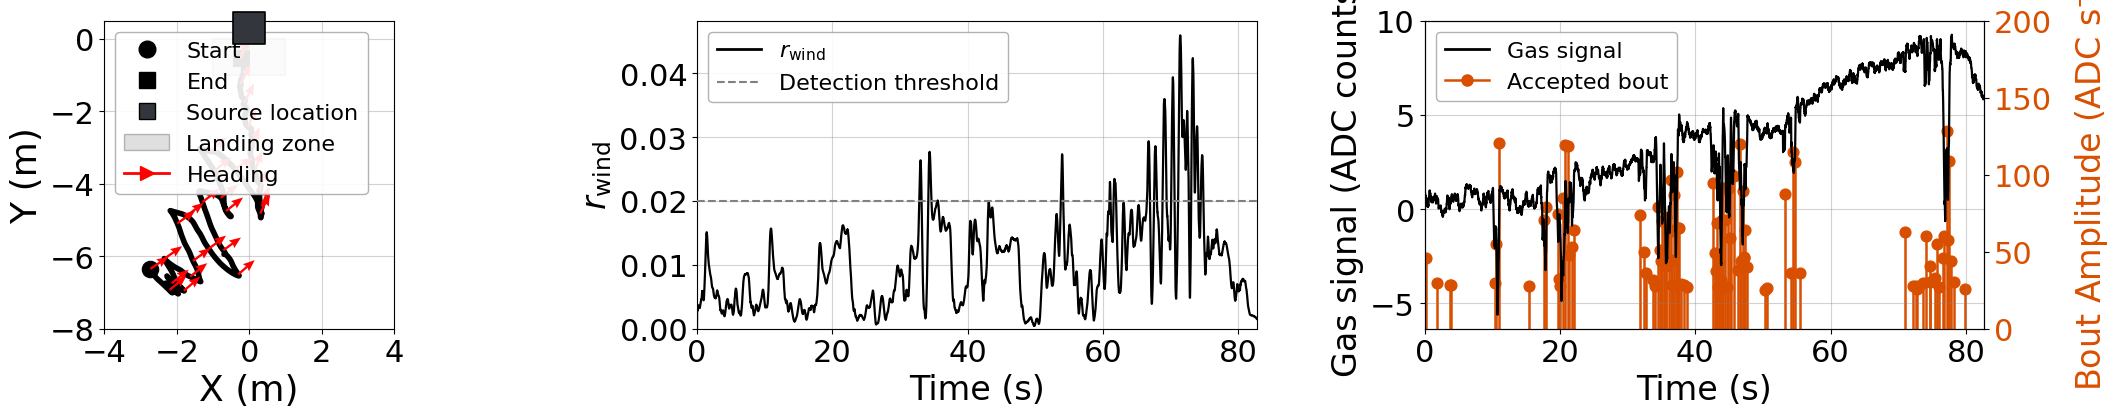

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path

plt.style.use('default')

# ── Files ─────────────────────────────────────────────────────────────────────
TRAJ_PATH = r"C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc2_UpRedo_run3.csv"
LOG_PATH  = r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc2_UpRedo3.csv"

# ── Constants ─────────────────────────────────────────────────────────────────
FAN_X_RAW = -1514.199707 / 1000
FAN_Y_RAW =  2919.908203 / 1000

COLOR        = 'black'
QUIVER_COLOR = 'red'
QUIVER_SCALE = 0.5
FAN_COLOR    = '#33373d'

FONT_TRAJ = 26
FONT_TS   = 24
TICK_TRAJ = 22
TICK_TS   = 22
FONT_LEG  = 16

# Log column names
COL_TIME       = 'Time'
COL_WIND       = 'Wind'
COL_GAS        = 'Gas'
COL_BOUT_AMP   = 'BoutAmp'
BOUT_THRESHOLD = 25

WIND_COLOR = 'black'
GAS_COLOR  = 'black'
BOUT_COLOR = '#d94f00'

LEG_KW = dict(loc='upper left', fontsize=FONT_LEG, frameon=True,
              framealpha=0.9, edgecolor='#aaaaaa')

# ── Helpers ───────────────────────────────────────────────────────────────────

def find_cfmrl_position_cols(filepath):
    with open(filepath) as f:
        lines = f.readlines()
    type_line  = lines[2].strip().split(',')
    name_line  = lines[3].strip().split(',')
    attr_line  = lines[5].strip().split(',')
    coord_line = lines[6].strip().split(',')
    x_col = y_col = None
    for i, (t, n, a, c) in enumerate(zip(type_line, name_line, attr_line, coord_line)):
        if n.strip() == 'CFMRL' and t.strip() == 'Rigid Body' and a.strip() == 'Position':
            if c.strip() == 'X': x_col = i
            elif c.strip() == 'Y': y_col = i
    return x_col, y_col


def find_cfmrl_rotation_z_col(filepath):
    with open(filepath) as f:
        lines = f.readlines()
    type_line  = lines[2].strip().split(',')
    name_line  = lines[3].strip().split(',')
    attr_line  = lines[5].strip().split(',')
    coord_line = lines[6].strip().split(',')
    for i, (t, n, a, c) in enumerate(zip(type_line, name_line, attr_line, coord_line)):
        if (n.strip() == 'CFMRL' and t.strip() == 'Rigid Body'
                and a.strip() == 'Rotation' and c.strip() == 'Y'):
            return i
    return None


def extract_trajectory_data(traj_path):
    x_col, y_col = find_cfmrl_position_cols(traj_path)
    rz_col       = find_cfmrl_rotation_z_col(traj_path)
    df  = pd.read_csv(traj_path, skiprows=6, header=0, low_memory=False)
    x   = pd.to_numeric(df.iloc[:, x_col],  errors='coerce')
    y   = pd.to_numeric(df.iloc[:, y_col],  errors='coerce')
    rz  = pd.to_numeric(df.iloc[:, rz_col], errors='coerce')
    mask = x.notna() & y.notna() & rz.notna()
    x  = x[mask].values - FAN_X_RAW
    y  = y[mask].values - FAN_Y_RAW
    rz = rz[mask].values
    return x, y, rz


def load_log(path):
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    t = pd.to_numeric(df[COL_TIME], errors='coerce').values
    t = (t - t[0]) * 1e-6   # µs → elapsed seconds
    return df, t


# ── Figure: 1 row × 3 cols ────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(26, 4),
    facecolor='white',
    gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.3}
)

ax_traj, ax_wind, ax_gas = axes

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 1 — Trajectory
# ═══════════════════════════════════════════════════════════════════════════════
ax_traj.set_facecolor('white')
ax_traj.set_xlim(-4,4)
ax_traj.set_ylim(-8, 0.5)
ax_traj.set_xlabel('X (m)', fontsize=FONT_TRAJ)
ax_traj.set_ylabel('Y (m)', fontsize=FONT_TRAJ)
ax_traj.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax_traj.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax_traj.grid(True, alpha=0.35, color='gray', zorder=0)
ax_traj.set_axisbelow(True)
ax_traj.tick_params(labelsize=TICK_TRAJ)

# Landing zone
rect = plt.Rectangle((-1, -1.0), 2, 1,
                      linewidth=1.5, edgecolor='black',
                      facecolor='gray', alpha=0.25, zorder=1)
ax_traj.add_patch(rect)

# Source marker
ax_traj.scatter(0, 0.3, color=FAN_COLOR, marker='s', s=500,
                zorder=11, edgecolors='black', linewidths=1.2, clip_on=False)

x, y, rz = extract_trajectory_data(TRAJ_PATH)
ax_traj.plot(x, y, color=COLOR, linewidth=4, zorder=4)
ax_traj.scatter(x[0],  y[0],  color=COLOR, marker='o', s=140,
                zorder=5, edgecolors='black', linewidths=0.8)
ax_traj.scatter(x[-1], y[-1], color=COLOR, marker='s', s=140,
                zorder=5, edgecolors='black', linewidths=0.8)
ax_traj.set_aspect('equal')
QUIVER_SCALE      = 15
QUIVER_WIDTH      = 0.008
idx = np.arange(0, len(x), 300)
yaw = np.deg2rad(-rz[idx])
u   = np.cos(yaw) * QUIVER_SCALE
v   = np.sin(yaw) * QUIVER_SCALE
ax_traj.quiver(x[idx], y[idx], u, v,
               color=QUIVER_COLOR,
               angles='uv', scale_units='xy', scale=25, headwidth=4,
               width=0.008, zorder=5)

# ── Panel 1 legend — quiver handle built from a real quiverkey proxy
q_proxy = ax_traj.quiver([0], [0], [0], [0],   # invisible dummy in data space
                         color=QUIVER_COLOR, angles='uv', scale_units='xy',
                         scale=1.6, headwidth=3, width=0.01, alpha=0)
traj_legend_elements = [
    Line2D([0], [0], color='none', marker='o', markersize=12,
           markerfacecolor=COLOR, markeredgecolor='black', label='Start'),
    Line2D([0], [0], color='none', marker='s', markersize=12,
           markerfacecolor=COLOR, markeredgecolor='black', label='End'),
    Line2D([0], [0], color='none', marker='s', markersize=12,
           markerfacecolor=FAN_COLOR, markeredgecolor='black', label='Source location'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='black', label='Landing zone'),
    # Arrow proxy: a right-pointing filled arrow line
    Line2D([0], [0], color=QUIVER_COLOR, linewidth=2,
           marker='>', markersize=10, markerfacecolor=QUIVER_COLOR,
           markeredgecolor=QUIVER_COLOR, label='Heading'),
]
ax_traj.legend(handles=traj_legend_elements, **LEG_KW)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 2 — Wind estimate
# ═══════════════════════════════════════════════════════════════════════════════
df, t = load_log(LOG_PATH)

ax_wind.set_facecolor('white')
wind = pd.to_numeric(df[COL_WIND], errors='coerce').values
# wind_smooth = windpd.rolling(30, center=True, min_periods=1).mean().values
ax_wind.plot(t, wind, color=WIND_COLOR, linewidth=1.6, zorder=3)
ax_wind.axhline(y=0.02, color='gray', linestyle='--', zorder=5)
ax_wind.set_xlabel('Time (s)', fontsize=FONT_TS)
ax_wind.set_ylabel(r'$r_{\mathrm{wind}}$', fontsize=FONT_TS)
ax_wind.tick_params(labelsize=TICK_TS)
ax_wind.set_xlim(t[0], t[-1])
ax_wind.set_ylim(bottom=0)
ax_wind.grid(True, alpha=0.35, color='gray', zorder=0)
ax_wind.set_axisbelow(True)

wind_legend_elements = [
    Line2D([0], [0], color=WIND_COLOR, linewidth=2,
           label=r'$r_{\mathrm{wind}}$'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--',
           label='Detection threshold'),
]
ax_wind.legend(handles=wind_legend_elements, **LEG_KW)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 3 — Gas signal (smoothed) + bout markers
# ═══════════════════════════════════════════════════════════════════════════════
ax_bout = ax_gas.twinx()

# ── fix draw order ────────────────────────────────────────────────────────────
ax_bout.set_zorder(ax_gas.get_zorder() - 1)   # push bout axis behind gas axis
ax_bout.patch.set_visible(False)               # keep background transparent
ax_gas.patch.set_visible(False)
# ─────────────────────────────────────────────────────────────────────────────
#ax_gas.set_facecolor('white')

gas        = pd.to_numeric(df[COL_GAS], errors='coerce')
gas_smooth = gas.rolling(30, center=True, min_periods=1).mean().values
ax_gas.plot(t, gas_smooth, color=GAS_COLOR, linewidth=1.6, zorder=3)
ax_gas.set_xlabel('Time (s)', fontsize=FONT_TS)
ax_gas.set_ylabel('Gas signal (ADC counts)', fontsize=FONT_TS)
ax_gas.tick_params(axis='y', labelsize=TICK_TS)
ax_gas.tick_params(axis='x', labelsize=TICK_TS)
ax_gas.set_xlim(t[0], t[-1])
ax_gas.grid(True, alpha=0.35, color='gray', zorder=0)
ax_gas.set_axisbelow(True)

# Bout markers — vertical line + circle at peak
if COL_BOUT_AMP in df.columns:
    bout     = pd.to_numeric(df[COL_BOUT_AMP], errors='coerce').values
    accepted = bout > BOUT_THRESHOLD
    changes  = np.diff(accepted.astype(int), prepend=0, append=0)
    starts   = np.where(changes ==  1)[0]
    ends     = np.where(changes == -1)[0]
    for s, e in zip(starts, ends):
        peak_amp = np.max(bout[s:e])
        peak_idx = s + np.argmax(bout[s:e])
        t_peak   = t[peak_idx]
        ax_bout.plot([t_peak, t_peak], [0, peak_amp],
                     color=BOUT_COLOR, linewidth=1.8, zorder=1)
        ax_bout.scatter(t_peak, peak_amp,
                        color=BOUT_COLOR, s=60, zorder=2,
                        edgecolors=BOUT_COLOR, linewidths=1.0)

ax_bout.set_ylabel(r'Bout Amplitude (ADC s$^{-1}$)',
                   color=BOUT_COLOR, fontsize=FONT_TS, labelpad=12)
ax_bout.tick_params(axis='y', labelcolor=BOUT_COLOR, labelsize=TICK_TS)
ax_bout.set_ylim(0,140)

gas_legend_elements = [
    Line2D([0], [0], color=GAS_COLOR, linewidth=2, label='Gas signal'),
    Line2D([0], [0], color=BOUT_COLOR, linewidth=1.8,
           marker='o', markersize=8, markerfacecolor=BOUT_COLOR,
           markeredgecolor=BOUT_COLOR, label='Accepted bout'),
]
# Place on ax_gas so it sits in front of the twin axis
ax_gas.legend(handles=gas_legend_elements, **LEG_KW)

plt.tight_layout()
plt.show()

Reading origin from file 0...
  Origin (raw): x=0.655, y=2.489


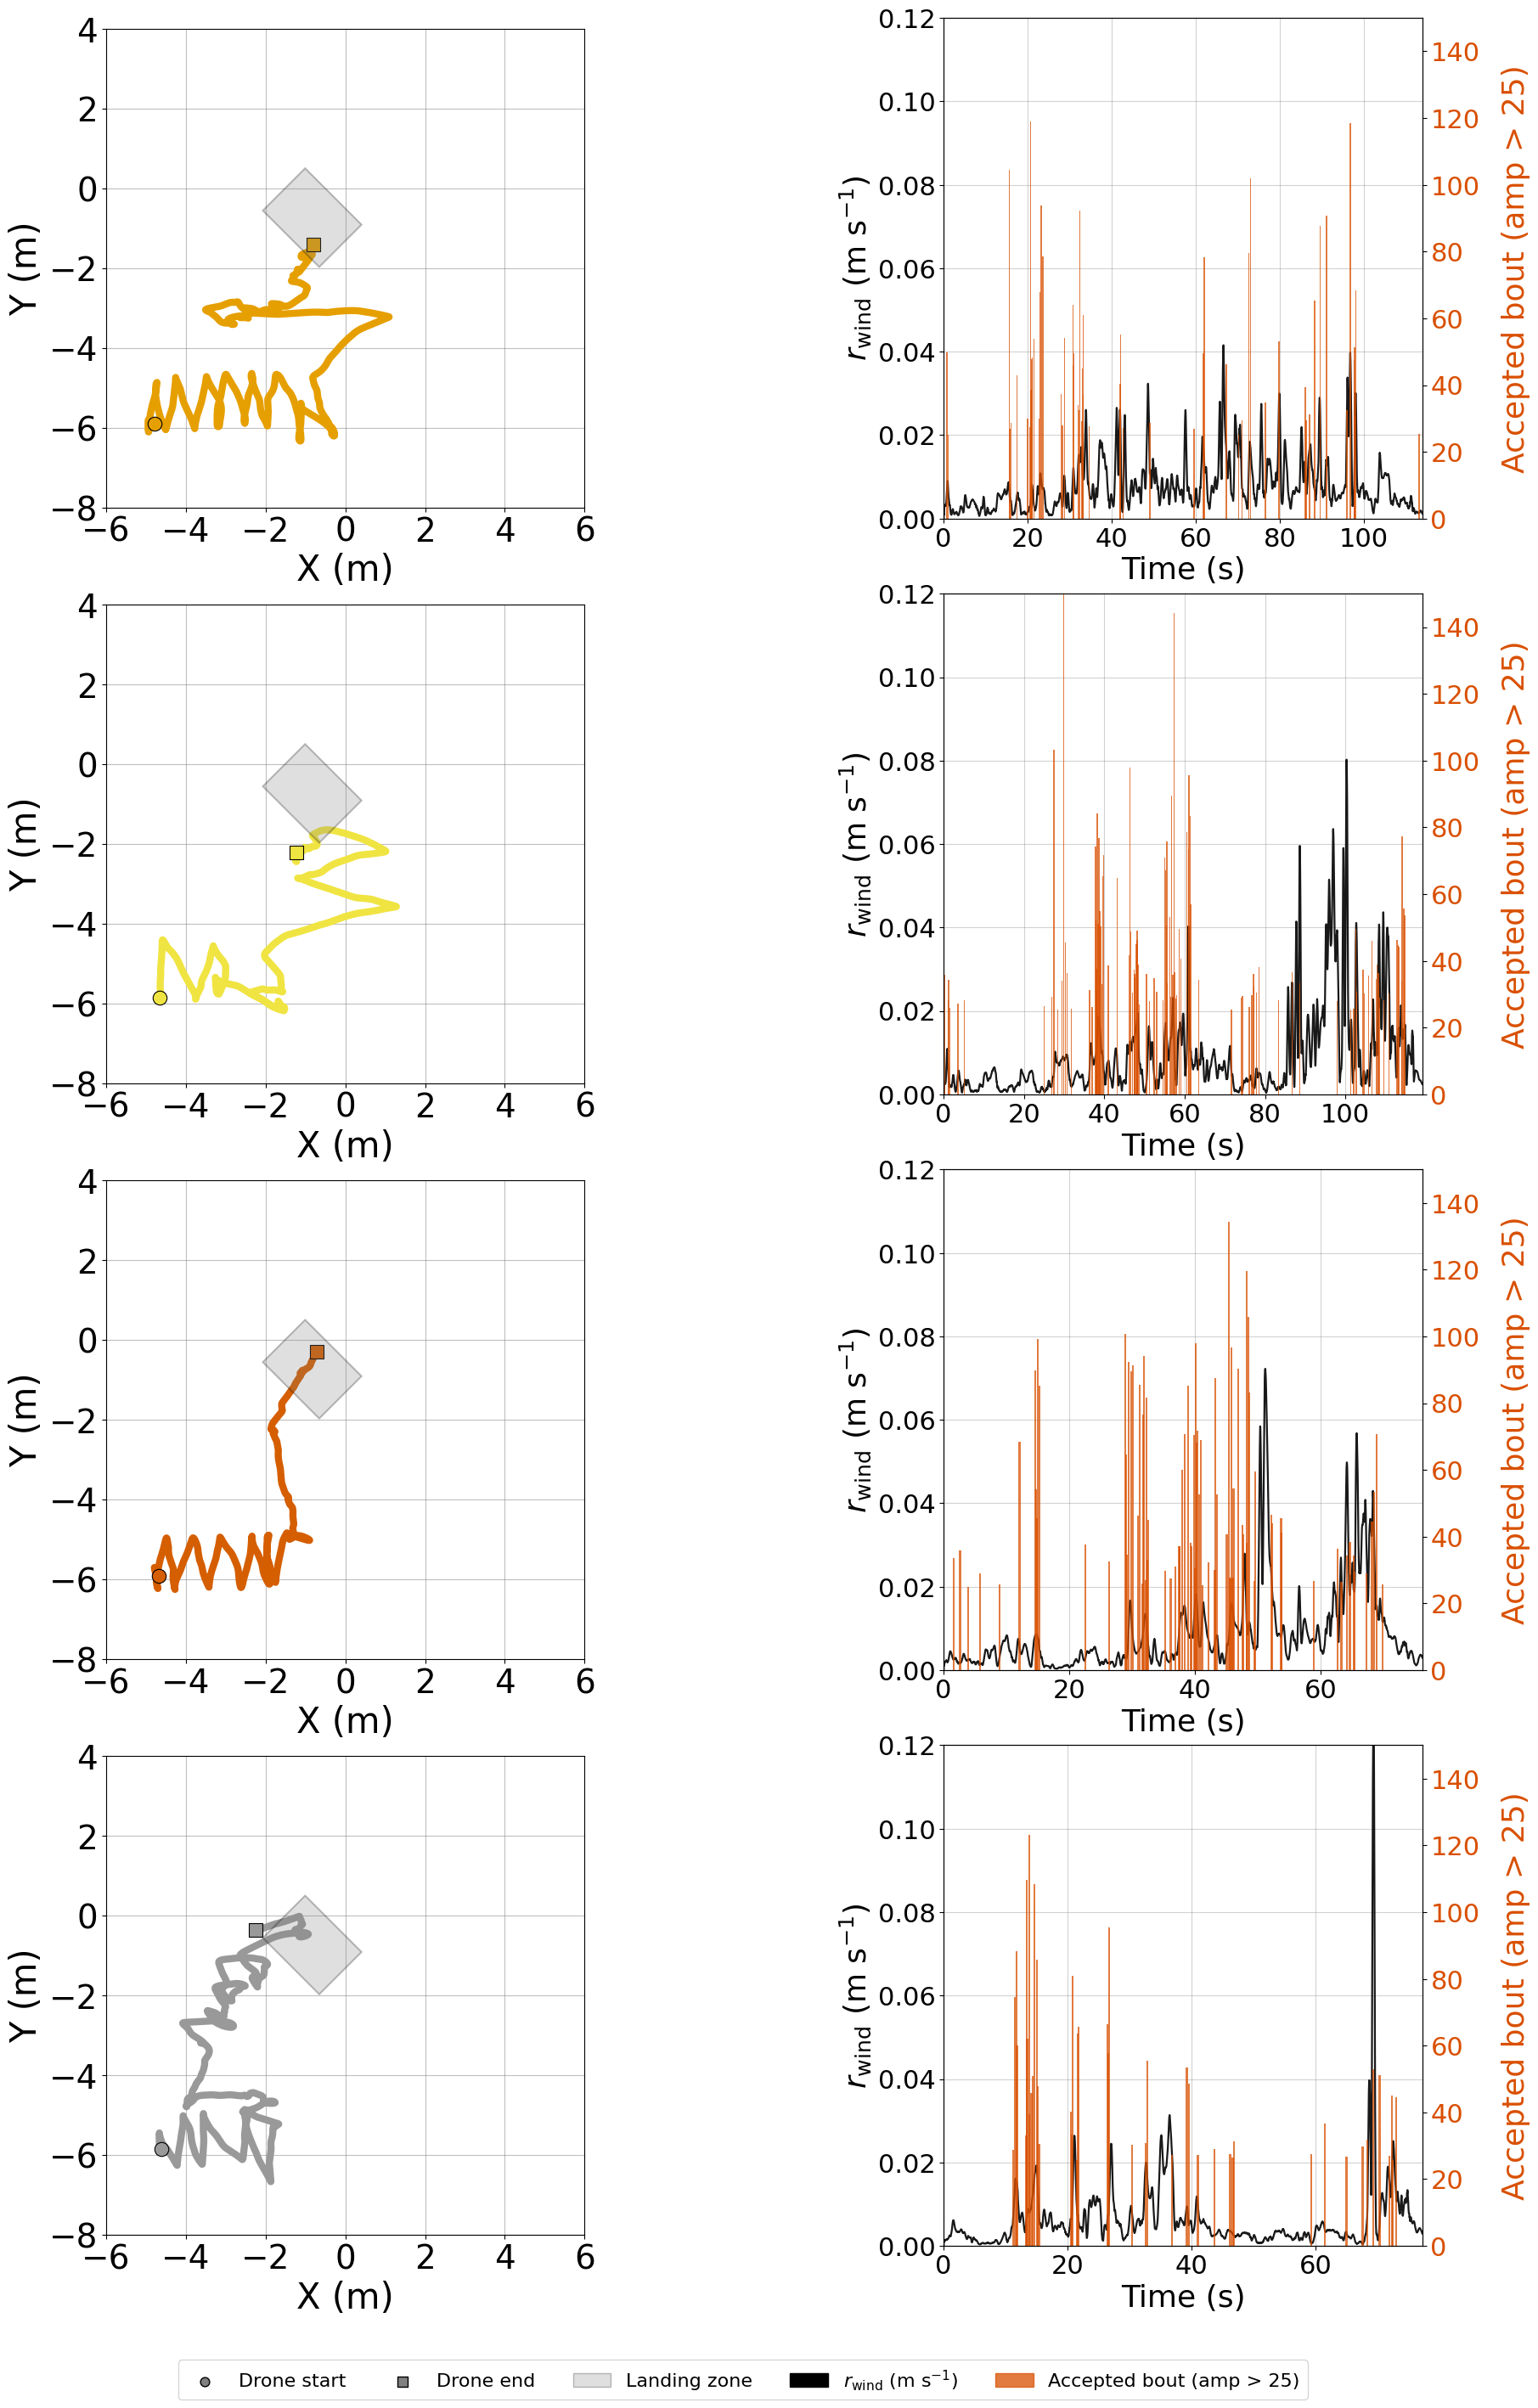

In [66]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches

plt.style.use('default')

# ── Trajectory (OptiTrack) files ──────────────────────────────────────────────
TRAJECTORY_FILES = r"""
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\ARR_NC_Shifting_5.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Shifting_3_worked_auto_far.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Shifting_2_worked_manual_end.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\ARR_NC_Shifting_miss.csv
"""

LOG_FILES = [
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting1_miss.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting5.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting2_worked_manualend.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting3_worked_auto_far.csv",
]

COL_TIME       = 'Time'
COL_WIND       = 'Wind'
COL_BOUT_AMP   = 'BoutAmp'
BOUT_THRESHOLD = 25

WIND_YLIM = (0, 0.12)
BOUT_YLIM = (0, 150)
RUN_COLORS = ['#E69F00', '#F0E442', '#D55E00', '#999999']  # amber, yellow, vermillion, gray
WIND_COLOR = 'black'
BOUT_COLOR = '#d94f00'

FONT_TRAJ = 30
FONT_TS   = 26
TICK_TRAJ = 28
TICK_TS   = 22

ZONE_WIDTH = 2.0
ZONE_DEPTH = 1.5


# ── Helpers ───────────────────────────────────────────────────────────────────

def find_rigid_body_position_cols(filepath, body_name):
    with open(filepath) as f:
        lines = f.readlines()
    name_line  = lines[3].strip().split(',')
    attr_line  = lines[5].strip().split(',')
    coord_line = lines[6].strip().split(',')
    x_col = y_col = None
    for i, (n, a, c) in enumerate(zip(name_line, attr_line, coord_line)):
        if n.strip() == body_name and a.strip() == 'Position':
            if c.strip() == 'X': x_col = i
            elif c.strip() == 'Y': y_col = i
    return x_col, y_col


def load_optitrack(filepath):
    return pd.read_csv(filepath, skiprows=6, header=0, low_memory=False)


def get_optitrack_origin(filepath):
    x_col, y_col = find_rigid_body_position_cols(filepath, 'Fan')
    df = load_optitrack(filepath)
    fx = pd.to_numeric(df.iloc[:, x_col], errors='coerce').dropna()
    fy = pd.to_numeric(df.iloc[:, y_col], errors='coerce').dropna()
    return fx.iloc[-1], fy.iloc[-1]


def rotate(points, angle_deg):
    a = np.radians(angle_deg)
    c, s = np.cos(a), np.sin(a)
    R = np.array([[c, -s], [s, c]])
    return points @ R.T


def load_log(path):
    try:
        df = pd.read_csv(path, low_memory=False)
        df.columns = df.columns.str.strip()
        return df
    except Exception as e:
        print(f"  [warn] Could not load {path}: {e}")
        return None


# ── Plotting ──────────────────────────────────────────────────────────────────

def plot_trajectory(ax, filepath, color, origin):
    ax.set_facecolor('white')
    origin_x, origin_y = origin

    # Axes formatting
    ax.set_xlim(-6, 6)
    ax.set_ylim(-8, 4)
    ax.set_xlabel('X (m)', fontsize=FONT_TRAJ)
    ax.set_ylabel('Y (m)', fontsize=FONT_TRAJ)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.set_aspect('equal')

    ax.tick_params(labelsize=TICK_TRAJ)

    # Landing zone — drawn after grid so alpha composites correctly
    zone2 = make_landing_zone((-0.3, -0.2), 135.0)
    ax.add_patch(Polygon(zone2, closed=True, linewidth=1.5,
                         edgecolor='black', facecolor='gray', alpha=0.25, zorder=10))
    ax.set_axisbelow('line')
    ax.grid(True, alpha=0.5, color='gray', zorder=0)
    # Drone trajectory
    df = load_optitrack(filepath)
    x_col, y_col = find_rigid_body_position_cols(filepath, 'CFMRL')
    x = pd.to_numeric(df.iloc[:, x_col], errors='coerce')
    y = pd.to_numeric(df.iloc[:, y_col], errors='coerce')
    mask = x.notna() & y.notna()
    x = x[mask].values - origin_x
    y = y[mask].values - origin_y

    line, = ax.plot(x, y, color=color, linewidth=6, zorder=4)
    ax.scatter(x[0],  y[0],  color=color, marker='o', s=140,
               zorder=5, edgecolors='black', linewidths=0.8)
    ax.scatter(x[-1], y[-1], color=color, marker='s', s=140,
               zorder=5, edgecolors='black', linewidths=0.8)

    return line


def plot_timeseries(ax_w, log_path):
    ax_b = ax_w.twinx()
    ax_w.set_facecolor('white')

    df = load_log(log_path)
    if df is None:
        return ax_b

    t = pd.to_numeric(df[COL_TIME], errors='coerce').values
    t = (t - t[0]) * 1e-6

    if COL_WIND in df.columns:
        wind = pd.to_numeric(df[COL_WIND], errors='coerce').values
        ax_w.plot(t, wind, color=WIND_COLOR, linewidth=1.6, alpha=0.9, zorder=3)
        ax_w.set_ylabel(r'$r_{\mathrm{wind}}$ (m s$^{-1}$)', color=WIND_COLOR, fontsize=FONT_TS)
        ax_w.tick_params(axis='y', labelcolor=WIND_COLOR, labelsize=TICK_TS)
        ax_w.set_ylim(WIND_YLIM)
        ax_w.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    if COL_BOUT_AMP in df.columns:
        bout     = pd.to_numeric(df[COL_BOUT_AMP], errors='coerce').values
        accepted = bout > BOUT_THRESHOLD
        changes  = np.diff(accepted.astype(int), prepend=0, append=0)
        starts   = np.where(changes ==  1)[0]
        ends     = np.where(changes == -1)[0]
        for s, e in zip(starts, ends):
            peak_amp = np.max(bout[s:e])
            t_s   = t[s]
            t_e   = t[min(e, len(t) - 1)]
            width = max(t_e - t_s, 0.3)
            ax_b.bar(t_s + width / 2, peak_amp, width=width,
                     color=BOUT_COLOR, alpha=0.75, zorder=2, align='center')
        ax_b.set_ylabel(f'Accepted bout (amp > {BOUT_THRESHOLD})',
                        color=BOUT_COLOR, fontsize=FONT_TS, labelpad=18)
        ax_b.tick_params(axis='y', labelcolor=BOUT_COLOR, labelsize=TICK_TS)
        ax_b.set_ylim(BOUT_YLIM)

    ax_w.set_xlabel('Time (s)', fontsize=FONT_TS)
    ax_w.tick_params(axis='x', labelsize=TICK_TS)
    ax_w.grid(True, alpha=0.35, color='gray', zorder=0)
    ax_w.set_xlim(t[0], t[-1])

    return ax_b


# ── Main ──────────────────────────────────────────────────────────────────────
traj_paths = [p.strip() for p in TRAJECTORY_FILES.strip().splitlines() if p.strip()]
n_runs = len(traj_paths)

print("Reading origin from file 0...")
origin = get_optitrack_origin(traj_paths[0])
print(f"  Origin (raw): x={origin[0]:.3f}, y={origin[1]:.3f}")

fig, axes = plt.subplots(
    n_runs, 2,
    figsize=(20, 8 * n_runs),
    facecolor='white',
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.75, 'hspace': 0.15}
)

twin_axes  = {}

for row, (traj_path, log_path) in enumerate(zip(traj_paths, LOG_FILES)):
    ax_traj = axes[row, 0]
    ax_wind = axes[row, 1]
    color   = RUN_COLORS[row % len(RUN_COLORS)]

    plot_trajectory(ax_traj, traj_path, color, origin)
    ax_bout = plot_timeseries(ax_wind, log_path)
    twin_axes[row] = ax_bout

# ── Shared legend below all subplots ─────────────────────────────────────────
legend_handles = [
    plt.scatter([], [], color='gray', marker='o', s=60,
                edgecolors='black', label='Drone start'),
    plt.scatter([], [], color='gray', marker='s', s=80,
                edgecolors='black', label='Drone end'),
    mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.25,
                   label='Landing zone'),
    mpatches.Patch(facecolor=WIND_COLOR, edgecolor=WIND_COLOR,
                   label=r'$r_{\mathrm{wind}}$ (m s$^{-1}$)'),
    mpatches.Patch(facecolor=BOUT_COLOR, edgecolor=BOUT_COLOR, alpha=0.75,
                   label=f'Accepted bout (amp > {BOUT_THRESHOLD})'),
]

fig.legend(legend_handles, [h.get_label() for h in legend_handles],
           loc='lower center',
           ncol=len(legend_handles),
           fontsize=16,
           frameon=True,
           bbox_to_anchor=(0.5, 0.0))

# Match timeseries height to trajectory height
fig.canvas.draw()
for row in range(n_runs):
    ax_traj = axes[row, 0]
    ax_wind = axes[row, 1]
    ax_bout = twin_axes[row]

    traj_pos = ax_traj.get_position()
    ts_pos   = ax_wind.get_position()
    new_pos  = [ts_pos.x0, traj_pos.y0, ts_pos.width, traj_pos.height]
    ax_wind.set_position(new_pos)
    ax_bout.set_position(new_pos)

plt.subplots_adjust(bottom=0.06)
plt.show()

Reading origin from file 0...
  Origin (raw): x=0.655, y=2.489


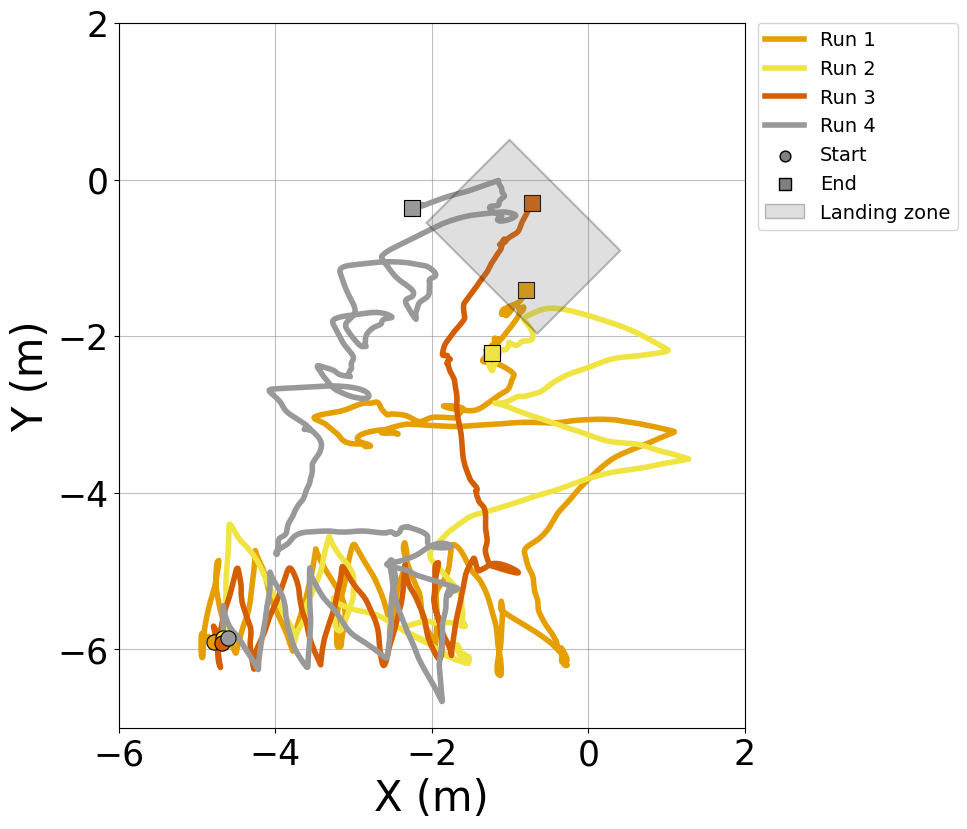

In [74]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches

plt.style.use('default')

# ── Trajectory (OptiTrack) files ──────────────────────────────────────────────
TRAJECTORY_FILES = r"""
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\ARR_NC_Shifting_5.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Shifting_3_worked_auto_far.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Shifting_2_worked_manual_end.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\ARR_NC_Shifting_miss.csv
"""

RUN_LABELS = ['Run 1', 'Run 2', 'Run 3', 'Run 4']

RUN_COLORS = ['#E69F00', '#F0E442', '#D55E00', '#999999']  # amber, yellow, vermillion, gray

FONT_TRAJ = 30
TICK_TRAJ = 25

ZONE_WIDTH = 2.0
ZONE_DEPTH = 1.5


# ── Helpers ───────────────────────────────────────────────────────────────────

def find_rigid_body_position_cols(filepath, body_name):
    with open(filepath) as f:
        lines = f.readlines()
    name_line  = lines[3].strip().split(',')
    attr_line  = lines[5].strip().split(',')
    coord_line = lines[6].strip().split(',')
    x_col = y_col = None
    for i, (n, a, c) in enumerate(zip(name_line, attr_line, coord_line)):
        if n.strip() == body_name and a.strip() == 'Position':
            if c.strip() == 'X': x_col = i
            elif c.strip() == 'Y': y_col = i
    return x_col, y_col


def load_optitrack(filepath):
    return pd.read_csv(filepath, skiprows=6, header=0, low_memory=False)


def get_optitrack_origin(filepath):
    x_col, y_col = find_rigid_body_position_cols(filepath, 'Fan')
    df = load_optitrack(filepath)
    fx = pd.to_numeric(df.iloc[:, x_col], errors='coerce').dropna()
    fy = pd.to_numeric(df.iloc[:, y_col], errors='coerce').dropna()
    return fx.iloc[-1], fy.iloc[-1]


def rotate(points, angle_deg):
    a = np.radians(angle_deg)
    c, s = np.cos(a), np.sin(a)
    R = np.array([[c, -s], [s, c]])
    return points @ R.T


def make_landing_zone(fan_pos, angle_deg, width=ZONE_WIDTH, depth=ZONE_DEPTH):
    half_w = width / 2
    local = np.array([
        [-half_w, 0],
        [ half_w, 0],
        [ half_w, depth],
        [-half_w, depth],
    ])
    return rotate(local, angle_deg) + np.array(fan_pos)


# ── Main ──────────────────────────────────────────────────────────────────────
traj_paths = [p.strip() for p in TRAJECTORY_FILES.strip().splitlines() if p.strip()]

print("Reading origin from file 0...")
origin = get_optitrack_origin(traj_paths[0])
origin_x, origin_y = origin
print(f"  Origin (raw): x={origin_x:.3f}, y={origin_y:.3f}")

fig, ax = plt.subplots(figsize=(10, 12), facecolor='white')
ax.set_facecolor('white')

# ── Axes formatting first so grid is underneath ───────────────────────────────
ax.set_xlim(-6, 2)
ax.set_ylim(-7, 2)
ax.set_xlabel('X (m)', fontsize=FONT_TRAJ)
ax.set_ylabel('Y (m)', fontsize=FONT_TRAJ)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.set_aspect('equal')
ax.set_axisbelow(True)
ax.grid(True, alpha=0.5, color='gray')
ax.tick_params(labelsize=TICK_TRAJ)

# ── Landing zone (drawn after grid) ──────────────────────────────────────────
zone2 = make_landing_zone((-0.3, -0.2), 135.0)
ax.add_patch(Polygon(zone2, closed=True, linewidth=1.5,
                     edgecolor='black', facecolor='gray', alpha=0.25, zorder=10))

# ── Trajectories ──────────────────────────────────────────────────────────────
traj_handles = []
for traj_path, color, label in zip(traj_paths, RUN_COLORS, RUN_LABELS):
    df = load_optitrack(traj_path)
    x_col, y_col = find_rigid_body_position_cols(traj_path, 'CFMRL')
    x = pd.to_numeric(df.iloc[:, x_col], errors='coerce')
    y = pd.to_numeric(df.iloc[:, y_col], errors='coerce')
    mask = x.notna() & y.notna()
    x = x[mask].values - origin_x
    y = y[mask].values - origin_y

    line, = ax.plot(x, y, color=color, linewidth=4, zorder=4, label=label)
    ax.scatter(x[0],  y[0],  color=color, marker='o', s=120,
               zorder=5, edgecolors='black', linewidths=0.8)
    ax.scatter(x[-1], y[-1], color=color, marker='s', s=120,
               zorder=5, edgecolors='black', linewidths=0.8)
    traj_handles.append(line)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = traj_handles + [
    plt.scatter([], [], color='gray', marker='o', s=60,
                edgecolors='black', label='Start'),
    plt.scatter([], [], color='gray', marker='s', s=80,
                edgecolors='black', label='End'),
    mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.25,
                   label='Landing zone'),
]

ax.legend(handles=legend_handles,
          labels=[h.get_label() for h in legend_handles],
          fontsize=14, loc='upper left', frameon=True,
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

plt.tight_layout()
plt.subplots_adjust(right=0.75)
plt.show()

Reading Fan origin...
  Fan origin (median): x=0.655, y=2.489
Loading CF log...
  CF log: 7622 rows, t=[-6.1, 70.1] s


C:\Users\ltjth\AppData\Local\Temp\ipykernel_6460\4016461807.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


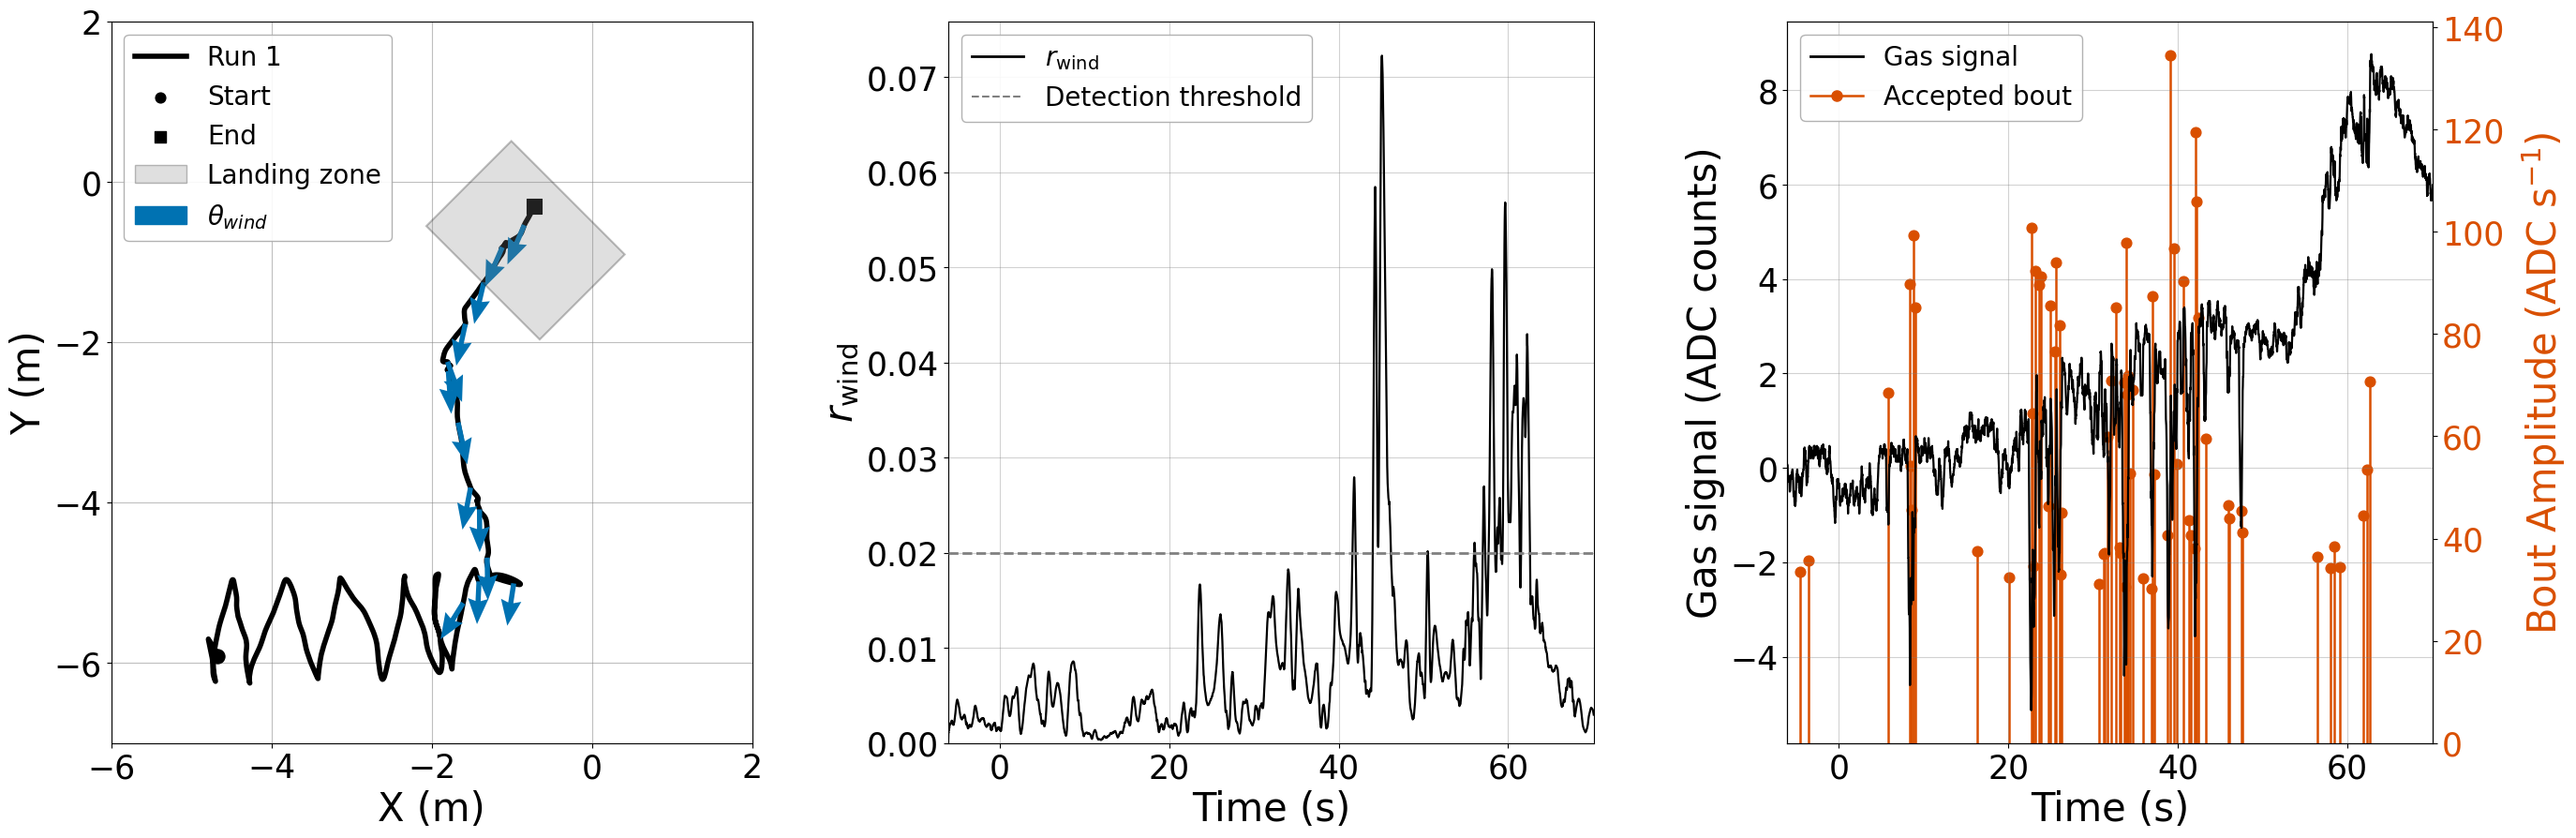

Drone first moves at OT time_s = -8.091 s


In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from datetime import datetime, timezone

plt.style.use('default')
CF_TIME_OFFSET_S = -6.091
# ── File paths ────────────────────────────────────────────────────────────────
TRAJECTORY_FILES = r"""C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Shifting_2_worked_manual_end.csv"""

# Path to the Crazyflie log CSV
CF_LOG_FILE = r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting2_worked_manualend.csv"

# ── Timing sync ───────────────────────────────────────────────────────────────
CF_START_US = 1772076402434880

# ── Quiver display settings ───────────────────────────────────────────────────
QUIVER_EVERY_N_SEC = 2
QUIVER_SCALE      = 15
QUIVER_WIDTH      = 0.008
QUIVER_COLOR      = '#0072B2'

# ── Plot style ────────────────────────────────────────────────────────────────
RUN_LABELS = ['Run 1', 'Run 2', 'Run 3', 'Run 4']
RUN_COLORS = ['black']
FONT_TRAJ  = 30
TICK_TRAJ  = 25
ZONE_WIDTH = 2.0
ZONE_DEPTH = 1.5

# ── Panel 2/3 style (from second script) ─────────────────────────────────────
FONT_TS      = 30
TICK_TS      = 25
FONT_LEG     = 20
WIND_COLOR   = 'black'
GAS_COLOR    = 'black'
BOUT_COLOR   = '#d94f00'
COL_WIND     = 'Wind'
COL_GAS      = 'Gas'
COL_BOUT_AMP = 'BoutAmp'
BOUT_THRESHOLD = 30
LEG_KW = dict(loc='upper left', fontsize=FONT_LEG, frameon=True,
              framealpha=0.9, edgecolor='#aaaaaa')


# ── Helpers ───────────────────────────────────────────────────────────────────

def find_rigid_body_position_cols(filepath, body_name):
    with open(filepath) as f:
        lines = f.readlines()
    name_line  = lines[3].strip().split(',')
    attr_line  = lines[5].strip().split(',')
    coord_line = lines[6].strip().split(',')
    x_col = y_col = None
    for i, (n, a, c) in enumerate(zip(name_line, attr_line, coord_line)):
        if n.strip() == body_name and a.strip() == 'Position':
            if c.strip() == 'X': x_col = i
            elif c.strip() == 'Y': y_col = i
    return x_col, y_col


def load_optitrack(filepath):
    return pd.read_csv(filepath, skiprows=6, header=0, low_memory=False)


def rotate(points, angle_deg):
    a = np.radians(angle_deg)
    c, s = np.cos(a), np.sin(a)
    R = np.array([[c, -s], [s, c]])
    return points @ R.T


def make_landing_zone(fan_pos, angle_deg, width=ZONE_WIDTH, depth=ZONE_DEPTH):
    half_w = width / 2
    local = np.array([
        [-half_w, 0],
        [ half_w, 0],
        [ half_w, depth],
        [-half_w, depth],
    ])
    return rotate(local, angle_deg) + np.array(fan_pos)


def load_cf_log(filepath):
    """Load Crazyflie log. Converts Time (µs epoch) to seconds since CF_START_US."""
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df['time_s'] = (df['Time'] - CF_START_US) / 1e6 + CF_TIME_OFFSET_S
    return df


def get_optitrack_time_s(df_ot):
    OT_START_STR = "2026-02-25 22:25:16.304"
    OT_FS        = 100.0

    ot_start_us = int(datetime.strptime(OT_START_STR, "%Y-%m-%d %H:%M:%S.%f")
                      .timestamp() * 1e6)
    n = len(df_ot)
    frame_us = ot_start_us + np.arange(n) * (1e6 / OT_FS)
    return (frame_us - CF_START_US) / 1e6


def interpolate_wind_onto_traj(traj_x, traj_y, traj_time_s, df_cf,
                                every_n_sec=QUIVER_EVERY_N_SEC):
    cf_t    = df_cf['time_s'].values
    cf_fa   = df_cf['FlowAngle'].values
    cf_wind = df_cf[COL_WIND].values

    WIND_THRESHOLD = 0.07
    above = np.where(cf_wind > WIND_THRESHOLD)[0]
    if len(above) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
    wind_start_t = cf_t[above[0]]

    t_min = max(traj_time_s[0], cf_t[0], wind_start_t)
    t_max = min(traj_time_s[-1], cf_t[-1])
    sample_times = np.arange(t_min, t_max, every_n_sec)

    qx, qy, qu, qv = [], [], [], []
    for t in sample_times:
        px = np.interp(t, traj_time_s, traj_x)
        py = np.interp(t, traj_time_s, traj_y)
        idx = np.argmin(np.abs(cf_t - t))
        fa_deg = cf_fa[idx]
        fa_rad = np.deg2rad(fa_deg)
        u = np.cos(fa_rad)
        v = np.sin(fa_rad)
        qx.append(px); qy.append(py)
        qu.append(u);  qv.append(v)

    return np.array(qx), np.array(qy), np.array(qu), np.array(qv)


# ── Main ──────────────────────────────────────────────────────────────────────
traj_paths = [p.strip() for p in TRAJECTORY_FILES.strip().splitlines() if p.strip()]

print("Reading Fan origin...")
origin_x = 0.655
origin_y = 2.489
print(f"  Fan origin (median): x={origin_x:.3f}, y={origin_y:.3f}")

print("Loading CF log...")
df_cf = load_cf_log(CF_LOG_FILE)
print(f"  CF log: {len(df_cf)} rows, t=[{df_cf['time_s'].iloc[0]:.1f}, {df_cf['time_s'].iloc[-1]:.1f}] s")

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(32, 10), facecolor='white')
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.3)

ax      = fig.add_subplot(gs[0, 0])   # trajectory
ax_wind = fig.add_subplot(gs[0, 1])   # wind residual
ax_gas  = fig.add_subplot(gs[0, 2])   # gas + bouts

ax.set_facecolor('white')
ax.set_xlim(-6, 2)
ax.set_ylim(-7, 2)
ax.set_xlabel('X (m)', fontsize=FONT_TRAJ)
ax.set_ylabel('Y (m)', fontsize=FONT_TRAJ)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.set_aspect('equal')
ax.set_axisbelow(True)
ax.grid(True, alpha=0.5, color='gray')
ax.tick_params(labelsize=TICK_TRAJ)

# ── Landing zone ──────────────────────────────────────────────────────────────
zone2 = make_landing_zone((-0.3, -0.2), 135.0)
ax.add_patch(Polygon(zone2, closed=True, linewidth=1.5,
                     edgecolor='black', facecolor='gray', alpha=0.25, zorder=10))

# ── Trajectories + wind quivers ───────────────────────────────────────────────
traj_handles   = []
quiver_handles = []

for traj_path, color, label in zip(traj_paths, RUN_COLORS, RUN_LABELS):
    df_ot = load_optitrack(traj_path)

    x_col, y_col = find_rigid_body_position_cols(traj_path, 'CFMRL')
    x = pd.to_numeric(df_ot.iloc[:, x_col], errors='coerce')
    y = pd.to_numeric(df_ot.iloc[:, y_col], errors='coerce')
    mask = x.notna() & y.notna()
    x = x[mask].values - origin_x
    y = y[mask].values - origin_y

    traj_time_s = get_optitrack_time_s(df_ot[mask])

    line, = ax.plot(x, y, color=color, linewidth=4, zorder=4, label=label)
    ax.scatter(x[0],  y[0],  color=color, marker='o', s=120,
               zorder=5, edgecolors='black', linewidths=0.8)
    ax.scatter(x[-1], y[-1], color=color, marker='s', s=120,
               zorder=5, edgecolors='black', linewidths=0.8)
    traj_handles.append(line)

    qx, qy, qu, qv = interpolate_wind_onto_traj(x, y, traj_time_s, df_cf)
    if len(qx):
        q = ax.quiver(qx, qy, -qv, -qu,
                      color=QUIVER_COLOR,
                      scale=QUIVER_SCALE,
                      width=QUIVER_WIDTH,
                      headwidth=4, headlength=5,
                      zorder=6)
        if not quiver_handles:
            quiver_handles.append(q)

# ── Trajectory legend ─────────────────────────────────────────────────────────
legend_handles = traj_handles + [
    plt.scatter([], [], color='black', marker='o', s=60,
                edgecolors='black', label='Start'),
    plt.scatter([], [], color='black', marker='s', s=80,
                edgecolors='black', label='End'),
    mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.25,
                   label='Landing zone'),
]
if quiver_handles:
    legend_handles.append(
        mpatches.FancyArrow(0, 0, 1, 0, width=0.3,
                            color=QUIVER_COLOR, label=r'${\theta}_{wind}$')
    )
ax.legend(handles=legend_handles,
          labels=[h.get_label() for h in legend_handles],
          fontsize=20, loc='upper left', frameon=True,
          framealpha=0.9, edgecolor='#aaaaaa')

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 2 — Wind residual
# ═══════════════════════════════════════════════════════════════════════════════
t_cf  = df_cf['time_s'].values
wind  = pd.to_numeric(df_cf[COL_WIND], errors='coerce').values

ax_wind.set_facecolor('white')
ax_wind.plot(t_cf, wind, color=WIND_COLOR, linewidth=1.6, zorder=3)
ax_wind.axhline(y=0.02, linewidth=2,color='gray', linestyle='--', zorder=5)
ax_wind.set_xlabel('Time (s)', fontsize=FONT_TS)
ax_wind.set_ylabel(r'$r_{\mathrm{wind}}$', fontsize=FONT_TS)
ax_wind.tick_params(labelsize=TICK_TS)
ax_wind.set_xlim(t_cf[0], t_cf[-1])
ax_wind.set_ylim(bottom=0)
ax_wind.grid(True, alpha=0.35, color='gray', zorder=0)
ax_wind.set_axisbelow(True)

wind_legend_elements = [
    Line2D([0], [0], color=WIND_COLOR, linewidth=2,
           label=r'$r_{\mathrm{wind}}$'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--',
           label='Detection threshold'),
]
ax_wind.legend(handles=wind_legend_elements, **LEG_KW)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 3 — Gas signal (smoothed) + bout markers
# ═══════════════════════════════════════════════════════════════════════════════
ax_bout = ax_gas.twinx()

ax_bout.set_zorder(ax_gas.get_zorder() - 1)
ax_bout.patch.set_visible(False)
ax_gas.patch.set_visible(False)

gas        = pd.to_numeric(df_cf[COL_GAS], errors='coerce')
gas_smooth = gas.rolling(30, center=True, min_periods=1).mean().values
ax_gas.plot(t_cf, gas_smooth, color=GAS_COLOR, linewidth=1.6, zorder=3)
ax_gas.set_xlabel('Time (s)', fontsize=FONT_TS)
ax_gas.set_ylabel('Gas signal (ADC counts)', fontsize=FONT_TS)
ax_gas.tick_params(axis='y', labelsize=TICK_TS)
ax_gas.tick_params(axis='x', labelsize=TICK_TS)
ax_gas.set_xlim(t_cf[0], t_cf[-1])
ax_gas.grid(True, alpha=0.35, color='gray', zorder=0)
ax_gas.set_axisbelow(True)

if COL_BOUT_AMP in df_cf.columns:
    bout     = pd.to_numeric(df_cf[COL_BOUT_AMP], errors='coerce').values
    accepted = bout > BOUT_THRESHOLD
    changes  = np.diff(accepted.astype(int), prepend=0, append=0)
    starts   = np.where(changes ==  1)[0]
    ends     = np.where(changes == -1)[0]
    for s, e in zip(starts, ends):
        peak_amp = np.max(bout[s:e])
        peak_idx = s + np.argmax(bout[s:e])
        t_peak   = t_cf[peak_idx]
        ax_bout.plot([t_peak, t_peak], [0, peak_amp],
                     color=BOUT_COLOR, linewidth=1.8, zorder=1)
        ax_bout.scatter(t_peak, peak_amp,
                        color=BOUT_COLOR, s=60, zorder=2,
                        edgecolors=BOUT_COLOR, linewidths=1.0)

ax_bout.set_ylabel(r'Bout Amplitude (ADC s$^{-1}$)',
                   color=BOUT_COLOR, fontsize=FONT_TS, labelpad=12)
ax_bout.tick_params(axis='y', labelcolor=BOUT_COLOR, labelsize=TICK_TS)
ax_bout.set_ylim(bottom=0)

gas_legend_elements = [
    Line2D([0], [0], color=GAS_COLOR, linewidth=2, label='Gas signal'),
    Line2D([0], [0], color=BOUT_COLOR, linewidth=1.8,
           marker='o', markersize=8, markerfacecolor=BOUT_COLOR,
           markeredgecolor=BOUT_COLOR, label='Accepted bout'),
]
ax_gas.legend(handles=gas_legend_elements, **LEG_KW)

plt.tight_layout()
plt.show()

# ── Sync diagnostic ───────────────────────────────────────────────────────────
df_ot = load_optitrack(traj_paths[0])
x_col, y_col = find_rigid_body_position_cols(traj_paths[0], 'CFMRL')
x_raw = pd.to_numeric(df_ot.iloc[:, x_col], errors='coerce').dropna()
y_raw = pd.to_numeric(df_ot.iloc[:, y_col], errors='coerce').dropna()

speed = np.sqrt(np.diff(x_raw.values)**2 + np.diff(y_raw.values)**2) * 100
first_move_idx = np.where(speed > 0.02)[0][0]
first_move_time_s = traj_time_s[first_move_idx]
print(f"Drone first moves at OT time_s = {first_move_time_s:.3f} s")

C:\Users\ltjth\AppData\Local\Temp\ipykernel_58280\1962433669.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(WIND_CMAP)


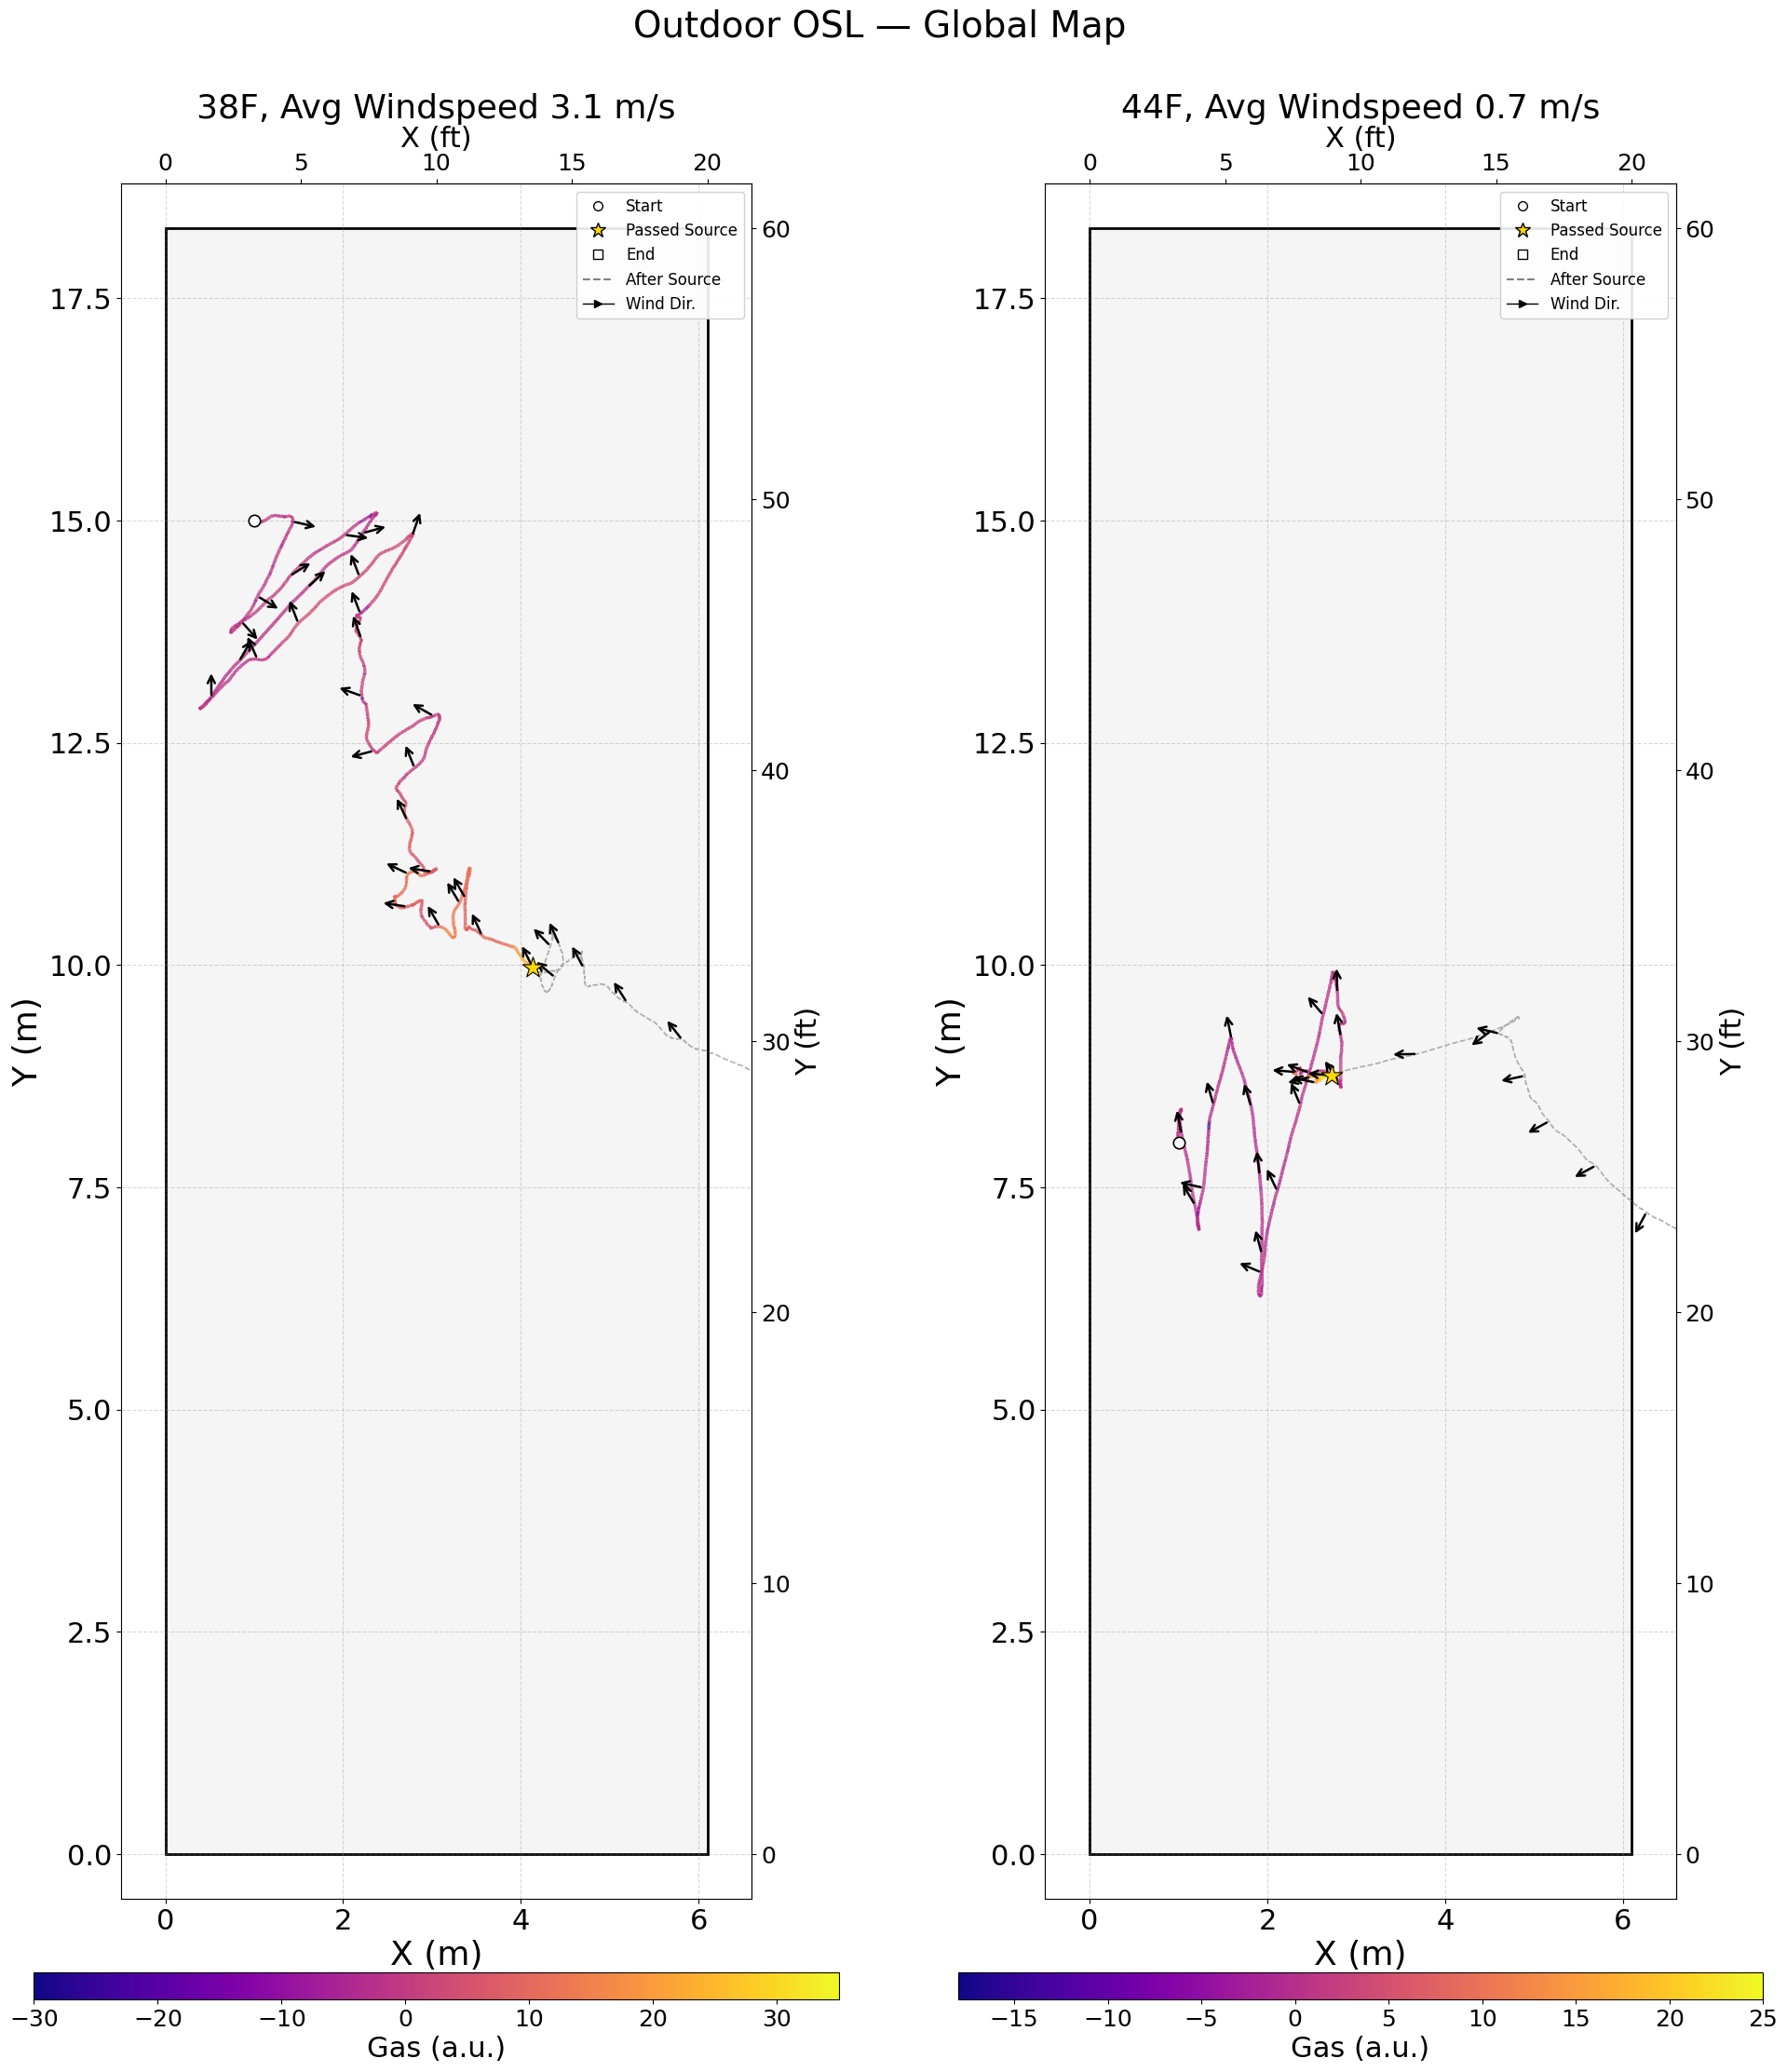

In [1]:
########################## OUTDOOR OSL – GLOBAL MAP ##########################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
plt.style.use('default')

# ─── STYLE ───────────────────────────────────────────────────────────────────
FONT_TS        = 26
TICK_TS        = 22
WIND_CMAP      = 'plasma'

FT_TO_M = 0.3048
FIELD_W = 20 * FT_TO_M
FIELD_H = 60 * FT_TO_M

# ─── FILES ───────────────────────────────────────────────────────────────────
files = {
    '38F, Avg Windspeed 3.1 m/s': (
        r'C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_alpha1_worked_passed_source.csv',
        5600
    ),
    '44F, Avg Windspeed 0.7 m/s': (
        r'C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_44F4_initial approach worked_passed_source.csv',
        4000
    ),
}

# ─── PLACEMENT ───────────────────────────────────────────────────────────────
RUN_PLACEMENT = {
    '38F, Avg Windspeed 3.1 m/s': {'x_global': 1,   'y_global': 15,  'heading_deg': 315},
    '44F, Avg Windspeed 0.7 m/s': {'x_global': 1,   'y_global': 8.0, 'heading_deg': 0},
}

def rotate_xy(x, y, deg):
    rad = np.deg2rad(deg)
    return x * np.cos(rad) - y * np.sin(rad), x * np.sin(rad) + y * np.cos(rad)

def make_line_collection(x, y, values, norm, cmap, linewidth=2.5, zorder=3):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    seg_vals = (values[:-1] + values[1:]) / 2
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=linewidth, zorder=zorder)
    lc.set_array(seg_vals)
    return lc

# ─── FIGURE ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 22), facecolor='white')
fig.subplots_adjust(wspace=0.35)

cmap = cm.get_cmap(WIND_CMAP)

for idx, (label, (path, split_idx)) in enumerate(files.items()):
    ax = axes[idx]
    ax.set_facecolor('white')
    placement = RUN_PLACEMENT[label]
    gx, gy, hdg = placement['x_global'], placement['y_global'], placement['heading_deg']

    df = pd.read_csv(path)
    x_loc      = df['PosX'].values - df['PosX'].values[0]
    y_loc      = df['PosY'].values - df['PosY'].values[0]
    flow_angle = df['FlowAngle'].values
    wind       = df['Gas'].values                          # raw wind for quiver onset check
    gas        = df['Gas'].values                          # gas drives colormap
    wind_smooth = pd.Series(wind).rolling(window=50, center=True, min_periods=1).mean().values
    n          = len(x_loc)
    split_idx  = min(split_idx, n - 1)

    x_rot, y_rot = rotate_xy(x_loc, y_loc, hdg)
    x_glob = x_rot + gx
    y_glob = y_rot + gy

    # ── Per-file norm based on Gas ────────────────────────────────────────────
    norm = mcolors.Normalize(vmin=gas.min(), vmax=gas.max())

    # ── First index where wind > 0.03 ────────────────────────────────────────
    wind_onset_indices = np.where(wind > 0.03)[0]
    quiver_start_idx   = wind_onset_indices[0] if len(wind_onset_indices) > 0 else 0

    # ── Field boundary
    field_rect = mpatches.Rectangle(
        (0, 0), FIELD_W, FIELD_H,
        linewidth=2, edgecolor='black', facecolor='#f5f5f5', zorder=0
    )
    ax.add_patch(field_rect)

    # ── Pre-source: gas-colored trajectory
    lc_pre = make_line_collection(
        x_glob[:split_idx+1], y_glob[:split_idx+1],
        gas[:split_idx+1], norm, cmap,
        linewidth=2.5, zorder=3
    )
    ax.add_collection(lc_pre)

    # ── Post-source: gray dashed
    ax.plot(x_glob[split_idx:], y_glob[split_idx:],
            color='gray', linewidth=1.2, linestyle='--', alpha=0.6, zorder=3)

    # ── Markers
    ax.scatter(x_glob[0],         y_glob[0],
               color='white', marker='o', s=80, zorder=5, edgecolors='black', linewidths=1.2)
    ax.scatter(x_glob[split_idx], y_glob[split_idx],
               color='gold',  marker='*', s=280, zorder=6, edgecolors='black', linewidths=0.8)
    ax.scatter(x_glob[-1],        y_glob[-1],
               color='white', marker='s', s=100, zorder=6, edgecolors='black', linewidths=1.2)

    # ── Wind direction arrows (only after quiver_start_idx, thicker)
    arrow_len = 0.3
    for i in range(0, len(x_glob), 200):
        if i < quiver_start_idx:
            continue
        angle_rad = np.deg2rad(flow_angle[i] + hdg + 180)
        dx = np.cos(angle_rad) * arrow_len
        dy = np.sin(angle_rad) * arrow_len
        ax.annotate('',
            xy=(x_glob[i] + dx, y_glob[i] + dy),
            xytext=(x_glob[i], y_glob[i]),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.8, mutation_scale=14),
            zorder=4)

    # ── Per-subplot colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.04, fraction=0.03, aspect=30)
    cbar.set_label('Gas (a.u.)', fontsize=FONT_TS - 4)
    cbar.ax.tick_params(labelsize=TICK_TS - 4)

    # ── Legend
    legend_handles = [
        mlines.Line2D([], [], color='black', marker='o', markersize=7,
                      linewidth=0, markerfacecolor='white', markeredgecolor='black', label='Start'),
        mlines.Line2D([], [], color='black', marker='*', markersize=12,
                      linewidth=0, markerfacecolor='gold',  markeredgecolor='black', label='Passed Source'),
        mlines.Line2D([], [], color='black', marker='s', markersize=7,
                      linewidth=0, markerfacecolor='white', markeredgecolor='black', label='End'),
        mlines.Line2D([], [], color='gray',  linestyle='--', linewidth=1.5, label='After Source'),
        mlines.Line2D([], [], color='black', marker='>', markersize=6,
                      linewidth=1.0, label='Wind Dir.'),
    ]
    ax.legend(handles=legend_handles, fontsize=12, framealpha=0.9, loc='upper right')

    # ── Axes formatting
    ax.set_xlim(-0.5, FIELD_W + 0.5)
    ax.set_ylim(-0.5, FIELD_H + 0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('X (m)', fontsize=FONT_TS)
    ax.set_ylabel('Y (m)', fontsize=FONT_TS)
    ax.set_title(label, fontsize=FONT_TS)
    ax.tick_params(labelsize=TICK_TS)
    ax.grid(True, alpha=0.3, linestyle='--', color='gray', zorder=1)

    ax_ft_x = ax.secondary_xaxis('top',   functions=(lambda m: m / FT_TO_M, lambda ft: ft * FT_TO_M))
    ax_ft_y = ax.secondary_yaxis('right', functions=(lambda m: m / FT_TO_M, lambda ft: ft * FT_TO_M))
    ax_ft_x.set_xlabel('X (ft)', fontsize=FONT_TS - 4)
    ax_ft_y.set_ylabel('Y (ft)', fontsize=FONT_TS - 4)
    ax_ft_x.tick_params(labelsize=TICK_TS - 4)
    ax_ft_y.tick_params(labelsize=TICK_TS - 4)

plt.suptitle('Outdoor OSL — Global Map', fontsize=FONT_TS + 2, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
#     '38F, Avg Windspeed 3.4 m/s': (r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_alpha_3.4ms1.csv", None),
#     '32F, Avg Windspeed 3.4 m/s':(r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_beta_1.2ms2.csv", None),
# '31F, Avg Windspeed 3.4 m/s':(r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_alpha_1.2ms2.csv", None)

In [45]:
####### MOTION COMPOSITE ########

import cv2
import numpy as np

def video_composite(video_path, output_path, every_n_frames=30, threshold=25):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps
    print(f"Video: {total_frames} frames, {fps:.1f} fps, {duration:.1f}s duration")

    start_sec = float(input(f"Start time in seconds (0 to {duration:.1f}): "))
    stop_sec = float(input(f"Stop time in seconds ({start_sec} to {duration:.1f}): "))

    start_frame = int(start_sec * fps)
    stop_frame = int(stop_sec * fps)

    # Seek to start frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    # Read frames in range
    all_frames = []
    for i in range(stop_frame - start_frame):
        ret, frame = cap.read()
        if not ret:
            break
        all_frames.append(frame)
    cap.release()
    print(f"Read {len(all_frames)} frames from {start_sec}s to {stop_sec}s")

    # Compute median background
    print("Computing background...")
    sample = np.array(all_frames[::5])
    background = np.median(sample, axis=0).astype(np.uint8)

    # Select frames to composite
    selected = all_frames[::every_n_frames]
    print(f"Compositing {len(selected)} frames...")

    # Build composite
    composite = background.copy()
    for i, frame in enumerate(selected):
        print(f"  Processing frame {i+1}/{len(selected)}")
        diff = cv2.absdiff(background, frame)
        gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
        mask = cv2.dilate(mask, np.ones((7, 7), np.uint8), iterations=2)
        composite[mask > 0] = frame[mask > 0]

    cv2.imwrite(output_path, composite)
    print(f"Saved to {output_path}")
#"C:\Users\ltjth\Downloads\ARR_NC_Loc2_UpRedo_run3-Camera 29 (M11498).avi" 92 start 147 end, 50 Hz , 100 frames
video_composite(r"C:\Users\ltjth\Downloads\ARR_NC_Loc2_UpRedo_run3-Camera 29 (M11498).avi", "ARR_fixed.png", every_n_frames=100)

Video: 11394 frames, 50.0 fps, 227.9s duration
Read 2750 frames from 92.0s to 147.0s
Computing background...


MemoryError: Unable to allocate 3.19 GiB for an array with shape (550, 1080, 1920, 3) and data type uint8

Processing data...

--- NO WIND ---

--- WITH WIND ---

Generating figure...


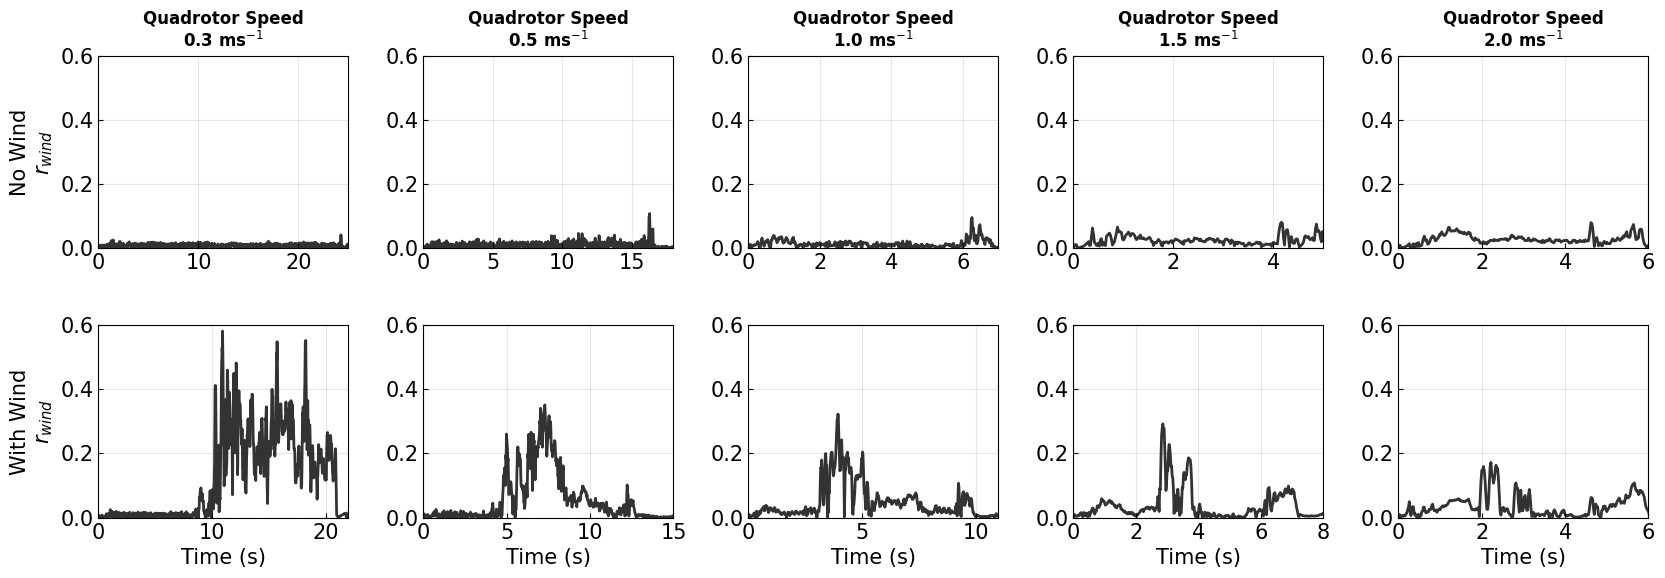

  2.0 ms-1: 1302 samples (13.0 s)


In [47]:
"""
Wind Comparison Analysis - Multi-Speed Comparison
Layout: 2 rows x 5 columns
  Row 0: Line - No Wind  | cols = speeds
  Row 1: Line - With Wind
"""

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import importlib
import liveWindUKF
importlib.reload(liveWindUKF)

# =============================================================================
# Data Loading
# =============================================================================

class CausalMovingAverage:
    """Causal (online/live) moving average filter using a fixed-size window."""

    def __init__(self, window=20):
        self.window = window
        self.buffer = deque(maxlen=window)

    def reset(self):
        self.buffer.clear()

    def update(self, value):
        self.buffer.append(value)
        return np.mean(self.buffer)

    def filter_array(self, data):
        self.reset()
        out = np.zeros(len(data))
        for i, v in enumerate(data):
            out[i] = self.update(v)
        return out


def load_data(filepath, ma_window=20):
    df = pd.read_csv(filepath)

    ma_x = CausalMovingAverage(window=ma_window)
    ma_y = CausalMovingAverage(window=ma_window)

    df['Bx_filt'] = ma_x.filter_array(df['Bx'].values)
    df['By_filt'] = ma_y.filter_array(df['By'].values)

    df['Bx_cf'] = df['Bx_filt']
    df['By_cf'] = df['By_filt']

    df['B_mag'] = np.sqrt(df['Bx_cf'] ** 2 + df['By_cf'] ** 2)
    df['Bxy_mag'] = df['B_mag']

    if all(col in df.columns for col in ['Qx', 'Qy', 'Qz']):
        qw_sq = 1.0 - (df['Qx'] ** 2 + df['Qy'] ** 2 + df['Qz'] ** 2)
        df['qw'] = np.sqrt(np.maximum(qw_sq, 0))

    if 'Vx' in df.columns:
        df['V_mag'] = np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2)

    return df


# =============================================================================
# Plotting
# =============================================================================

def plot_comparison(results_no_wind, results_wind, speeds,
                    xlim_line_no_wind,
                    xlim_line_wind,
                    title_fontsize=12,
                    label_fontsize=15,
                    tick_fontsize=15):

    n_speeds = len(speeds)
    fig, axes = plt.subplots(2, n_speeds, figsize=(4 * n_speeds, 6),
                             gridspec_kw={'hspace': 0.4, 'wspace': 0.3})

    color_wind = '#000000'

    rows = [
        (results_no_wind, xlim_line_no_wind, 'No Wind'),
        (results_wind,    xlim_line_wind,    'With Wind'),
    ]

    for row_idx, (results_dict, xlim_dict, row_label) in enumerate(rows):
        for col_idx, speed in enumerate(speeds):
            ax = axes[row_idx, col_idx]

            if speed not in results_dict:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=label_fontsize)
                ax.set_xlim([0, xlim_dict.get(speed, 17)])
            else:
                res = results_dict[speed]
                ax.plot(res['time'], res['wind'],
                        color=color_wind, lw=2, alpha=0.8)
                # ax.plot(res['time'], res['V_mag'], lw=2, alpha=0.8)
                ax.set_ylim(0,0.6)
                ax.set_xlim([0, xlim_dict.get(speed, 17)])
                ax.axhline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
                ax.grid(True, alpha=0.3)

            ax.tick_params(axis='both', labelsize=tick_fontsize,
                           direction='in')

            if row_idx == 0:
                ax.set_title(f'Quadrotor Speed\n{speed} ms$^{{-1}}$',
                             fontsize=title_fontsize, fontweight='bold')

            if row_idx == 1:
                ax.set_xlabel('Time (s)', fontsize=label_fontsize)

            if col_idx == 0:
                ax.set_ylabel(f'{row_label}\n$r_{{wind}}$', fontsize=label_fontsize)

    return fig


# =============================================================================
# File paths
# =============================================================================

base_path = r"C:\Users\ltjth\Documents\Research\UKF_Data"

files_wind = {
    0.3: f"{base_path}\\CF_ARR_Line_EKF0.3ms_FAN1.csv",
    0.5: f"{base_path}\\CF_ARR_Line_EKF0.5ms_FAN1.csv",
    1.0: f"{base_path}\\CF_ARR_Line_EKF1.0ms_4.5m_FAN1.csv",
    1.5: f"{base_path}\\CF_ARR_Line_EKF1.5ms_4.5m_FAN1.csv",
    2.0: f"{base_path}\\CF_ARR_Line_EKF2.0ms_4.5m_FAN1.csv",
}

files_no_wind = {
    0.3: f"{base_path}\\CF_ARR_Line_EKF0.31.csv",
    0.5: f"{base_path}\\CF_ARR_Line_EKF0.53.csv",
    1.0: f"{base_path}\\CF_ARR_Line_EKF1.0ms1.csv",
    1.5: f"{base_path}\\CF_ARR_Line_EKF1.5ms1.csv",
    2.0: f"{base_path}\\CF_ARR_Line_EKF2.0ms_4.5m2.csv",
}

speeds = [0.3, 0.5, 1.0, 1.5, 2.0]

xlim_line_no_wind = {0.3: 25,  0.5: 18, 1.0: 7,  1.5: 5, 2.0: 6}
xlim_line_wind    = {0.3: 22,  0.5: 15, 1.0: 11, 1.5: 8, 2.0: 6}

TITLE_FONTSIZE = 12
LABEL_FONTSIZE = 15
TICK_FONTSIZE  = 15

# =============================================================================
# Main — load and run UKF
# =============================================================================

print("=" * 60)
print("Processing data...")
print("=" * 60)

results_no_wind = {}
results_wind    = {}

for label, files_dict, results_dict in [
    ('NO WIND',   files_no_wind, results_no_wind),
    ('WITH WIND', files_wind,    results_wind),
]:
    print(f"\n--- {label} ---")
    for speed in speeds:
        filepath = files_dict[speed]
        try:
            df = load_data(filepath,ma_window=20)

            liveWindUKF.reset_ukf()  # fresh UKF for each trial

            n = len(df)
            airspeed  = np.zeros(n)
            wind      = np.zeros(n)
            empirical = np.zeros(n)

            for i in range(n):
                airspeed[i], wind[i], empirical[i] = liveWindUKF.run_ukf(
                    df['FlowMag'].iloc[i],
                    df['V_mag'].iloc[i]
                )

            results_dict[speed] = {
                'time':      np.arange(len(df)) / 50,
                'airspeed':  airspeed,
                'wind':      wind,
                'empirical': empirical,
                'V_mag':     df['V_mag'].values,
            }

        except FileNotFoundError:
            print(f"  {speed} ms-1: file not found")
        except Exception as e:
            print(f"  {speed} ms-1: error - {e}")

print("\nGenerating figure...")
fig = plot_comparison(
    results_no_wind, results_wind, speeds,
    xlim_line_no_wind,
    xlim_line_wind,
    title_fontsize=TITLE_FONTSIZE,
    label_fontsize=LABEL_FONTSIZE,
    tick_fontsize=TICK_FONTSIZE,
)

# fig.savefig('wind_comparison.png', dpi=500, bbox_inches='tight')
# fig.savefig('wind_comparison.pdf', bbox_inches='tight')

plt.show()
df = load_data(filepath, ma_window=20)
print(f"  {speed} ms-1: {len(df)} samples ({len(df)/100:.1f} s)")

Accepted bouts: 13


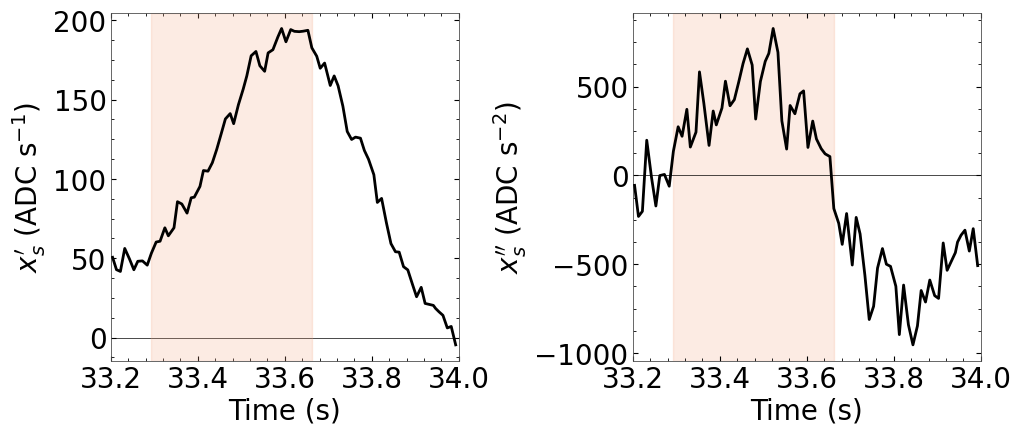

In [4]:
############# DERIVATIVE PANELS ###################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

mpl.rcParams['font.family']      = 'sans-serif'
mpl.rcParams['font.sans-serif']  = ['DejaVu Sans']
mpl.rcParams['font.size']        = 20
mpl.rcParams['axes.titlesize']   = 12
mpl.rcParams['axes.labelsize']   = 20
mpl.rcParams['xtick.labelsize']  = 20
mpl.rcParams['ytick.labelsize']  = 20
mpl.rcParams['legend.fontsize']  = 15
mpl.rcParams['axes.xmargin']     = 0

# ── Colour palette ────────────────────────────────────────────────────────
C_SHADE   = '#F4A582'

# ── Time window for derivative panels ────────────────────────────────────
DERIV_T1 = 33.2   # start time (s)
DERIV_T2 = 34.0   # end time   (s)

# ── Pipeline parameters ───────────────────────────────────────────────────
fs        = 100.0
hl        = 0.025
ampthresh = 25
sd_thr    = 0.0

# ── EWMA / bout-detection helper ──────────────────────────────────────────
def run_pipeline(gas, fs=100.0, hl=0.025, ampthresh=25, sd_thr=0.0):
    alpha = 1 - np.exp(-np.log(2) / (hl * fs))
    N = len(gas)
    xs      = np.zeros(N)
    xp_raw  = np.zeros(N)
    xp_s    = np.zeros(N)
    xpp_raw = np.zeros(N)
    xpp_s   = np.zeros(N)

    xs[0] = gas[0]
    for i in range(1, N):
        xs[i] = alpha * gas[i] + (1 - alpha) * xs[i-1]
    for i in range(1, N):
        xp_raw[i] = fs * (xs[i] - xs[i-1])
    xp_s[0] = xp_raw[0]
    for i in range(1, N):
        xp_s[i] = alpha * xp_raw[i] + (1 - alpha) * xp_s[i-1]
    for i in range(1, N):
        xpp_raw[i] = fs * (xp_s[i] - xp_s[i-1])
    xpp_s[0] = xpp_raw[0]
    for i in range(1, N):
        xpp_s[i] = alpha * xpp_raw[i] + (1 - alpha) * xpp_s[i-1]

    bout_regions = []
    in_bout, bout_start, bout_derivs = False, None, []
    for i in range(2, N):
        rising = xpp_s[i] > sd_thr
        if rising and not in_bout:
            in_bout, bout_start, bout_derivs = True, i, [xp_s[i]]
        elif rising and in_bout:
            bout_derivs.append(xp_s[i])
        elif not rising and in_bout:
            in_bout = False
            amp = max(bout_derivs) - min(bout_derivs)
            bout_regions.append({'start': bout_start, 'end': i,
                                  'amp': amp, 'accepted': amp > ampthresh})
            bout_derivs = []

    accepted = [b for b in bout_regions if b['accepted']]
    return xs, xp_s, xpp_s, accepted, alpha

# ── Load data ─────────────────────────────────────────────────────────────
PRIMARY = r"C:\Users\ltjth\Documents\Research\UKF_Data\Outside Data\outdoorBout_manualnotFlying_44F_avg0.41.csv"
df    = pd.read_csv(PRIMARY)
t_raw = (df['Time'] - df['Time'].iloc[0]) * 1e-6
gas   = df['Gas'].values.astype(float)
t     = t_raw.values
xs, xp_s, xpp_s, accepted_bouts, _ = run_pipeline(gas, fs, hl, ampthresh, sd_thr)
print(f"Accepted bouts: {len(accepted_bouts)}")

# ── Build snippet mask ────────────────────────────────────────────────────
deriv_mask = (t >= DERIV_T1) & (t <= DERIV_T2)
t_snip   = t[deriv_mask]
xp_snip  = xp_s[deriv_mask]
xpp_snip = xpp_s[deriv_mask]

visible_bouts = [b for b in accepted_bouts
                 if t[b['end']] >= DERIV_T1 and t[b['start']] <= DERIV_T2]

# ── Style helper ──────────────────────────────────────────────────────────
def style_ax(ax, ylabel):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color('0.3')
    ax.tick_params(which='both', direction='in', top=True, right=True, pad=3)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax.set_ylabel(ylabel, labelpad=4)
    ax.set_xlabel('Time (s)', labelpad=3)

# ── Figure ────────────────────────────────────────────────────────────────
lineThick = 2
fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor('white')
gs = GridSpec(1, 2, figure=fig, wspace=0.5,
              top=0.93, bottom=0.14, left=0.10, right=0.97)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# 1st derivative
ax1.axhline(0, color='black', linewidth=0.5, zorder=1)
ax1.plot(t_snip, xp_snip, color='black', linewidth=lineThick, zorder=3)
added = False
for b in visible_bouts:
    lbl = 'Bout region' if not added else '_'
    added = True
    ax1.axvspan(t[b['start']], t[b['end']], alpha=0.22, color=C_SHADE, zorder=2, label=lbl)
style_ax(ax1, r"$x^\prime_s$ (ADC s$^{-1}$)")
ax1.set_xlim(DERIV_T1, DERIV_T2)
ax1.set_box_aspect(1)

# 2nd derivative
ax2.plot(t_snip, xpp_snip, color='black', linewidth=lineThick, zorder=3)
ax2.axhline(0, color='black', linewidth=0.5, zorder=1)
for b in visible_bouts:
    ax2.axvspan(t[b['start']], t[b['end']], alpha=0.22, color=C_SHADE, zorder=0)
style_ax(ax2, r"$x^{\prime\prime}_s$ (ADC s$^{-2}$)")
ax2.set_xlim(DERIV_T1, DERIV_T2)
ax2.set_box_aspect(1)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(500))

fig.align_ylabels([ax1, ax2])
plt.show()

Accepted bouts: 13


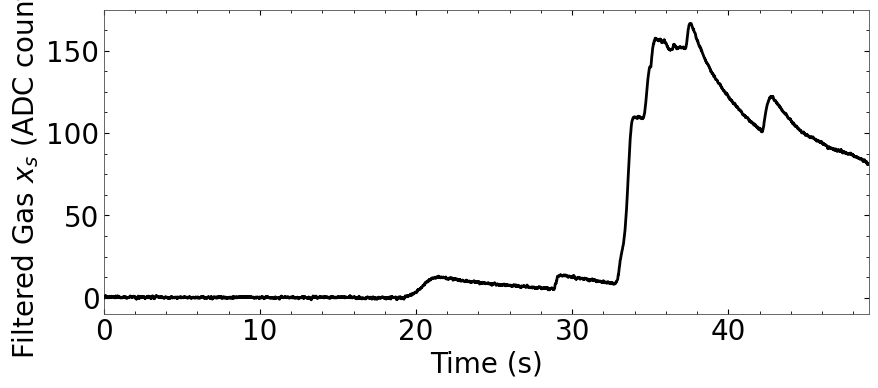

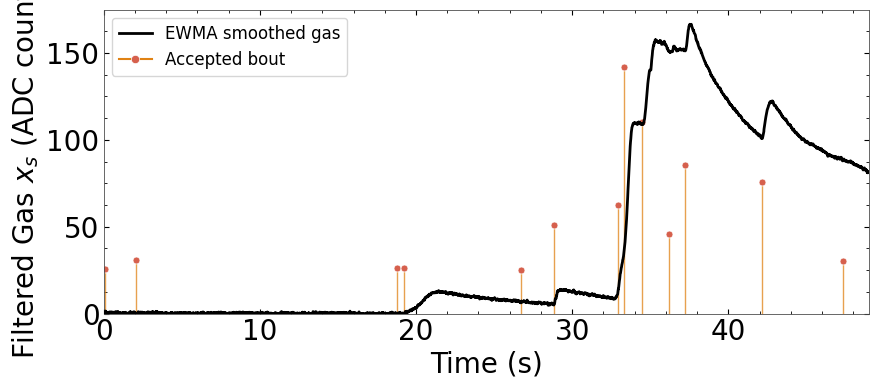

In [7]:
############# FILTERED GAS SIGNAL PLOTS ###################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib as mpl

mpl.rcParams['font.family']      = 'sans-serif'
mpl.rcParams['font.sans-serif']  = ['DejaVu Sans']
mpl.rcParams['font.size']        = 20
mpl.rcParams['axes.titlesize']   = 12
mpl.rcParams['axes.labelsize']   = 20
mpl.rcParams['xtick.labelsize']  = 20
mpl.rcParams['ytick.labelsize']  = 20
mpl.rcParams['legend.fontsize']  = 15
mpl.rcParams['axes.xmargin']     = 0

# ── Colour palette ────────────────────────────────────────────────────────
C_BOUT    = '#D6604D'
C_VLINE_S = '#E08214'

# ── Pipeline parameters ───────────────────────────────────────────────────
fs        = 100.0
hl        = 0.025
ampthresh = 25
sd_thr    = 0.0

# ── EWMA / bout-detection helper ──────────────────────────────────────────
def run_pipeline(gas, fs=100.0, hl=0.025, ampthresh=25, sd_thr=0.0):
    alpha = 1 - np.exp(-np.log(2) / (hl * fs))
    N = len(gas)
    xs      = np.zeros(N)
    xp_raw  = np.zeros(N)
    xp_s    = np.zeros(N)
    xpp_raw = np.zeros(N)
    xpp_s   = np.zeros(N)

    xs[0] = gas[0]
    for i in range(1, N):
        xs[i] = alpha * gas[i] + (1 - alpha) * xs[i-1]
    for i in range(1, N):
        xp_raw[i] = fs * (xs[i] - xs[i-1])
    xp_s[0] = xp_raw[0]
    for i in range(1, N):
        xp_s[i] = alpha * xp_raw[i] + (1 - alpha) * xp_s[i-1]
    for i in range(1, N):
        xpp_raw[i] = fs * (xp_s[i] - xp_s[i-1])
    xpp_s[0] = xpp_raw[0]
    for i in range(1, N):
        xpp_s[i] = alpha * xpp_raw[i] + (1 - alpha) * xpp_s[i-1]

    bout_regions = []
    in_bout, bout_start, bout_derivs = False, None, []
    for i in range(2, N):
        rising = xpp_s[i] > sd_thr
        if rising and not in_bout:
            in_bout, bout_start, bout_derivs = True, i, [xp_s[i]]
        elif rising and in_bout:
            bout_derivs.append(xp_s[i])
        elif not rising and in_bout:
            in_bout = False
            amp = max(bout_derivs) - min(bout_derivs)
            bout_regions.append({'start': bout_start, 'end': i,
                                  'amp': amp, 'accepted': amp > ampthresh})
            bout_derivs = []

    accepted = [b for b in bout_regions if b['accepted']]
    return xs, xp_s, xpp_s, accepted, alpha

# ── Load data ─────────────────────────────────────────────────────────────
PRIMARY = r"C:\Users\ltjth\Documents\Research\UKF_Data\Outside Data\outdoorBout_manualnotFlying_44F_avg0.41.csv"
df    = pd.read_csv(PRIMARY)
t_raw = (df['Time'] - df['Time'].iloc[0]) * 1e-6
gas   = df['Gas'].values.astype(float)
t     = t_raw.values
xs, xp_s, xpp_s, accepted_bouts, _ = run_pipeline(gas, fs, hl, ampthresh, sd_thr)
print(f"Accepted bouts: {len(accepted_bouts)}")

# ── Style helper ──────────────────────────────────────────────────────────
def style_ax(ax, ylabel):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color('0.3')
    ax.tick_params(which='both', direction='in', top=True, right=True, pad=3)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax.set_ylabel(ylabel, labelpad=4)
    ax.set_xlabel('Time (s)', labelpad=3)

lineThick = 2

# ══════════════════════════════════════════════════════════════════════════
# Plot 1 — Filtered gas signal only
# ══════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(9, 4))
fig1.patch.set_facecolor('white')
fig1.subplots_adjust(top=0.92, bottom=0.16, left=0.12, right=0.97)

ax.plot(t, xs, color='black', linewidth=lineThick, zorder=3)
style_ax(ax, 'Filtered Gas $x_s$ (ADC counts)')

plt.show()

# ══════════════════════════════════════════════════════════════════════════
# Plot 2 — Filtered gas signal + bout stems
# ══════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(9, 4))
fig2.patch.set_facecolor('white')
fig2.subplots_adjust(top=0.92, bottom=0.16, left=0.12, right=0.97)

ax.plot(t, xs, color='black', linewidth=lineThick, zorder=3)

if accepted_bouts:
    bout_t   = np.array([t[b['start']] for b in accepted_bouts])
    bout_amp = np.array([b['amp']      for b in accepted_bouts])
    markerline, stemlines, baseline = ax.stem(
        bout_t, bout_amp, markerfmt='o', basefmt=' ')
    plt.setp(stemlines, color=C_VLINE_S, linewidth=1.0, alpha=0.75)
    markerline.set_markerfacecolor(C_BOUT)
    markerline.set_markeredgecolor('white')
    markerline.set_markeredgewidth(0.5)
    markerline.set_markersize(5)
    ax.set_ylim(bottom=0)

style_ax(ax, 'Filtered Gas $x_s$ (ADC counts)')

legend_elements = [
    Line2D([0], [0], color='black', linewidth=lineThick, label='EWMA smoothed gas'),
    Line2D([0], [0], color=C_VLINE_S, linewidth=1.5,
           marker='o', markerfacecolor=C_BOUT, markeredgecolor='white',
           markeredgewidth=0.5, markersize=6, label='Accepted bout'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12,
          frameon=True, handlelength=2.0)

plt.show()

44°F Avg Wind Speed: 1.3 ms$^{-1}$ | 100% Ethanol — accepted bouts: 8
44°F Avg Wind Speed: 2.8 ms$^{-1}$ | 100% Ethanol — accepted bouts: 5
38°F Avg Wind Speed: 0.4 ms$^{-1}$ | 100% Ethanol — accepted bouts: 73
72°F Avg Wind Speed: 0.8 ms$^{-1}$ | 33% Ethanol — accepted bouts: 92


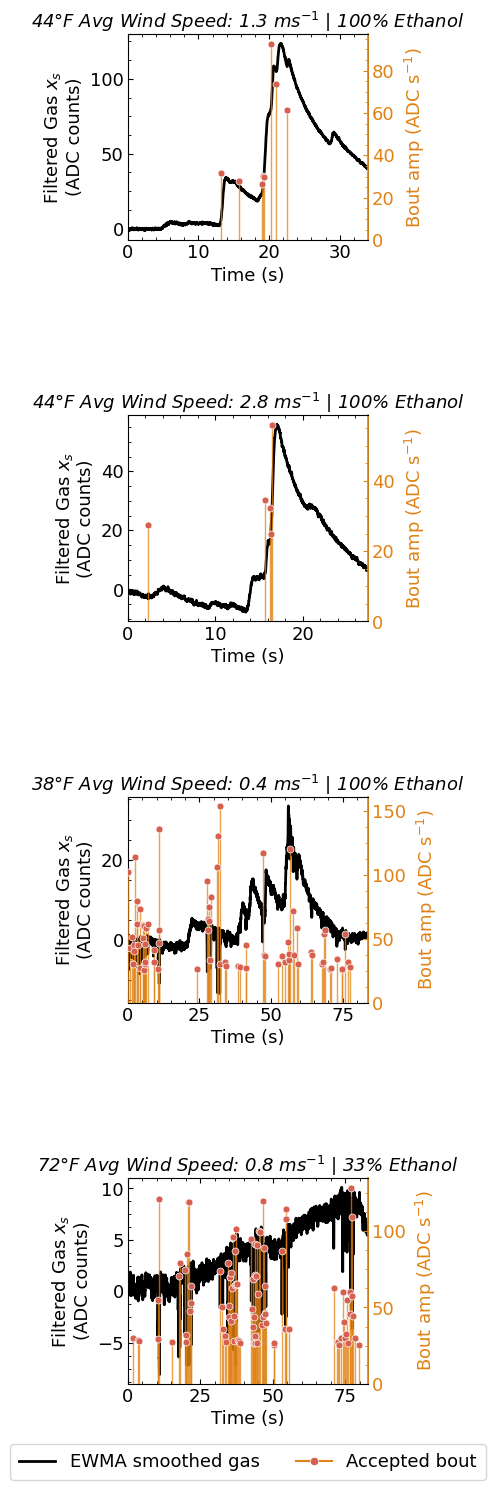

In [1]:
############# RC FILES — GAS SIGNAL + BOUT SPIKES ###################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib as mpl

mpl.rcParams['font.family']      = 'sans-serif'
mpl.rcParams['font.sans-serif']  = ['DejaVu Sans']
mpl.rcParams['font.size']        = 14
mpl.rcParams['axes.titlesize']   = 13
mpl.rcParams['axes.labelsize']   = 13
mpl.rcParams['xtick.labelsize']  = 13
mpl.rcParams['ytick.labelsize']  = 13
mpl.rcParams['legend.fontsize']  = 13
mpl.rcParams['axes.xmargin']     = 0

# ── Colour palette ────────────────────────────────────────────────────────
C_BOUT    = '#D6604D'
C_VLINE_S = '#E08214'

# ── Pipeline parameters ───────────────────────────────────────────────────
fs        = 100.0
hl        = 0.025
ampthresh = 25
sd_thr    = 0.0

# ── Files and labels ──────────────────────────────────────────────────────
RC_FILES = [
    r"C:\Users\ltjth\Documents\Research\UKF_Data\Outside Data\outdoorBout_manualnotFlying_44F_avg1.31.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\Outside Data\outdoorBout_manualnotFlying_44F_avg2.81.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_alpha1_worked_passed_source.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc2_UpRedo3.csv",
]
RC_LABELS = [
    r'44°F Avg Wind Speed: 1.3 ms$^{-1}$ | 100% Ethanol',
    r'44°F Avg Wind Speed: 2.8 ms$^{-1}$ | 100% Ethanol',
    r'38°F Avg Wind Speed: 0.4 ms$^{-1}$ | 100% Ethanol',
    r'72°F Avg Wind Speed: 0.8 ms$^{-1}$ | 33% Ethanol',
]

# ── EWMA / bout-detection helper ──────────────────────────────────────────
def run_pipeline(gas, fs=100.0, hl=0.025, ampthresh=25, sd_thr=0.0):
    alpha = 1 - np.exp(-np.log(2) / (hl * fs))
    N = len(gas)
    xs      = np.zeros(N)
    xp_raw  = np.zeros(N)
    xp_s    = np.zeros(N)
    xpp_raw = np.zeros(N)
    xpp_s   = np.zeros(N)

    xs[0] = gas[0]
    for i in range(1, N):
        xs[i] = alpha * gas[i] + (1 - alpha) * xs[i-1]
    for i in range(1, N):
        xp_raw[i] = fs * (xs[i] - xs[i-1])
    xp_s[0] = xp_raw[0]
    for i in range(1, N):
        xp_s[i] = alpha * xp_raw[i] + (1 - alpha) * xp_s[i-1]
    for i in range(1, N):
        xpp_raw[i] = fs * (xp_s[i] - xp_s[i-1])
    xpp_s[0] = xpp_raw[0]
    for i in range(1, N):
        xpp_s[i] = alpha * xpp_raw[i] + (1 - alpha) * xpp_s[i-1]

    bout_regions = []
    in_bout, bout_start, bout_derivs = False, None, []
    for i in range(2, N):
        rising = xpp_s[i] > sd_thr
        if rising and not in_bout:
            in_bout, bout_start, bout_derivs = True, i, [xp_s[i]]
        elif rising and in_bout:
            bout_derivs.append(xp_s[i])
        elif not rising and in_bout:
            in_bout = False
            amp = max(bout_derivs) - min(bout_derivs)
            bout_regions.append({'start': bout_start, 'end': i,
                                  'amp': amp, 'accepted': amp > ampthresh})
            bout_derivs = []

    accepted = [b for b in bout_regions if b['accepted']]
    return xs, xp_s, xpp_s, accepted, alpha

# ── Style helper ──────────────────────────────────────────────────────────
def style_ax(ax, ax2, title):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color('0.3')
    ax.tick_params(which='both', direction='in', top=True, right=False, pad=3)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax.set_title(title, fontsize=13, pad=4, style='italic')
    ax.set_ylabel('Filtered Gas $x_s$\n(ADC counts)', labelpad=4, fontsize=13)
    ax.set_xlabel('Time (s)', labelpad=3, fontsize=13)

    # Orange styling for right axis
    ax2.spines['right'].set_color(C_VLINE_S)
    ax2.spines['right'].set_linewidth(1.2)
    ax2.tick_params(which='both', direction='in', pad=3,
                    colors=C_VLINE_S, labelcolor=C_VLINE_S)
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax2.set_ylabel(r'Bout amp (ADC s$^{-1}$)', labelpad=6,
                   fontsize=13, color=C_VLINE_S)
    ax2.yaxis.label.set_color(C_VLINE_S)

# ── Load all files ────────────────────────────────────────────────────────
lineThick = 2
datasets = []
for path, label in zip(RC_FILES, RC_LABELS):
    df    = pd.read_csv(path)
    t     = (df['Time'] - df['Time'].iloc[0]).values * 1e-6
    gas   = df['Gas'].values.astype(float)
    xs, _, _, bouts, _ = run_pipeline(gas, fs, hl, ampthresh, sd_thr)
    print(f"{label} — accepted bouts: {len(bouts)}")
    datasets.append({'t': t, 'xs': xs, 'bouts': bouts, 'label': label})

# ══════════════════════════════════════════════════════════════════════════
# Figure — Smoothed gas signal + bout stems (4×1), independent axes
# ══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(4, 15))          # narrow width, tall height
fig.patch.set_facecolor('white')
gs = GridSpec(4, 1, figure=fig, hspace=0.85,
              top=0.97, bottom=0.07, left=0.20, right=0.80)

for idx, d in enumerate(datasets):
    ax  = fig.add_subplot(gs[idx])
    ax2 = ax.twinx()

    ax.plot(d['t'], d['xs'], color='black', linewidth=lineThick, zorder=3)

    if d['bouts']:
        bout_t   = np.array([d['t'][b['start']] for b in d['bouts']])
        bout_amp = np.array([b['amp']            for b in d['bouts']])
        markerline, stemlines, baseline = ax2.stem(
            bout_t, bout_amp, markerfmt='o', basefmt=' ')
        plt.setp(stemlines, color=C_VLINE_S, linewidth=1.0, alpha=0.75, zorder=5)
        markerline.set_markerfacecolor(C_BOUT)
        markerline.set_markeredgecolor('white')
        markerline.set_markeredgewidth(0.5)
        markerline.set_markersize(5)
        markerline.set_zorder(6)
        ax2.set_ylim(bottom=0)

    style_ax(ax, ax2, d['label'])

# Shared legend below the figure
legend_elements = [
    Line2D([0], [0], color='black', linewidth=lineThick, label='EWMA smoothed gas'),
    Line2D([0], [0], color=C_VLINE_S, linewidth=1.5,
           marker='o', markerfacecolor=C_BOUT, markeredgecolor='white',
           markeredgewidth=0.5, markersize=6, label='Accepted bout'),
]
fig.legend(handles=legend_elements, loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncol=2, fontsize=13,
           frameon=True, handlelength=2.0, borderpad=0.5)

plt.show()

Loading data...
Running UKF (no wind)...
Running UKF (with wind)...

No-wind   — mean airspeed: 0.263 ± 0.224 m/s
With-wind — mean airspeed: 0.255 ± 0.313 m/s

Generating figure...
Saved: wind_comparison_05ms.png / .pdf


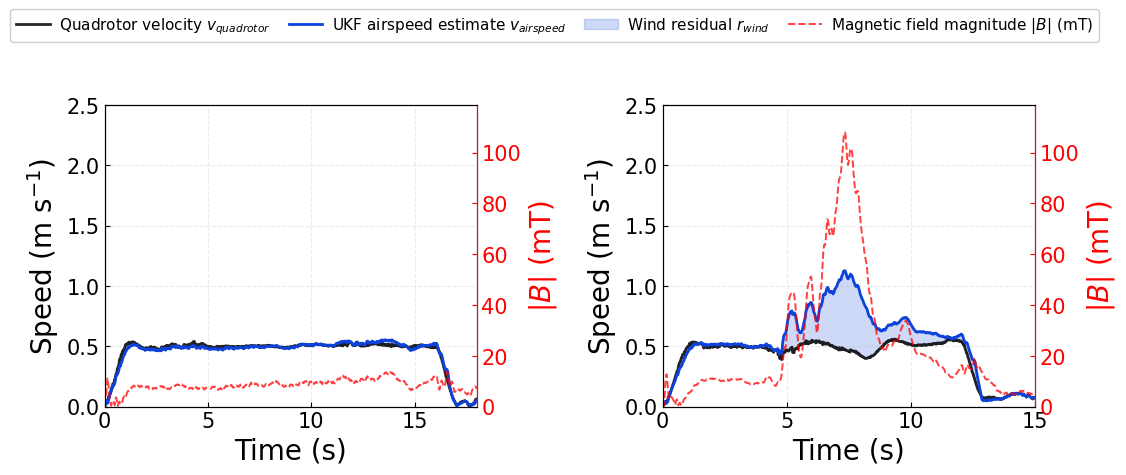

In [10]:
"""
Wind Comparison - 0.5 m/s Line Trajectory
Layout: 1 row x 2 columns
  Col 0: No Wind
  Col 1: With Wind

Uses scalar magnitude-only AirflowMagnitudeUKF (liveWindUKF architecture).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import UnscentedKalmanFilter as UKF
from filterpy.kalman import MerweScaledSigmaPoints
from collections import deque

# =============================================================================
# Data Loading
# =============================================================================

class CausalMovingAverage:
    def __init__(self, window=20):
        self.window = window
        self.buffer = deque(maxlen=window)

    def reset(self):
        self.buffer.clear()

    def update(self, value):
        self.buffer.append(value)
        return np.mean(self.buffer)

    def filter_array(self, data):
        self.reset()
        out = np.zeros(len(data))
        for i, v in enumerate(data):
            out[i] = self.update(v)
        return out


def load_data(filepath, ma_window=20):
    df = pd.read_csv(filepath)

    ma_x = CausalMovingAverage(window=ma_window)
    ma_y = CausalMovingAverage(window=ma_window)

    df['Bx_filt'] = ma_x.filter_array(df['Bx'].values)
    df['By_filt'] = ma_y.filter_array(df['By'].values)

    df['Bx_cf'] = df['Bx_filt']
    df['By_cf'] = df['By_filt']
    df['B_mag'] = np.sqrt(df['Bx_cf'] ** 2 + df['By_cf'] ** 2)

    if all(col in df.columns for col in ['Qx', 'Qy', 'Qz']):
        qw_sq = 1.0 - (df['Qx'] ** 2 + df['Qy'] ** 2 + df['Qz'] ** 2)
        df['qw'] = np.sqrt(np.maximum(qw_sq, 0))

    if 'Vx' in df.columns and 'Vy' in df.columns:
        df['V_mag'] = np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2)

    return df


# =============================================================================
# Scalar Magnitude-Only UKF  (from liveWindUKF)
# =============================================================================

class AirflowMagnitudeUKF:
    """
    UKF estimating relative airflow magnitude only.
    State:       [va_mag]  - airflow speed magnitude
    Measurement: [B_mag]   - magnetic field magnitude
    """

    def __init__(self, dt, Q_airflow=0.005, R_magnetic=0.74, R_odom=0.003):
        self.dt     = dt
        self.R_odom = R_odom

        # Inverse model coefficients (B -> v)
        self.inv_a = -0.000213
        self.inv_b =  0.03955
        self.inv_c =  0.03621

        self.dim_x = 1
        self.dim_z = 1

        points = MerweScaledSigmaPoints(n=1, alpha=0.1, beta=2.0, kappa=0.0)

        self.ukf = UKF(
            dim_x=1, dim_z=1, dt=dt,
            fx=self._fx, hx=self._hx,
            points=points
        )

        self.ukf.x = np.array([0.0])
        self.ukf.P = np.array([[1.0]])
        self.ukf.Q = np.array([[Q_airflow]])
        self.ukf.R = np.array([[R_magnetic]])

    def _fx(self, x, dt):
        return x

    def _hx(self, x):
        va_mag = np.maximum(x[0], 0)
        a, b, c = 29.47, -7.7, 5.44          # December forward model
        return np.array([a * va_mag**2 + b * va_mag + c])

    def predict(self):
        self.ukf.P = 0.5 * (self.ukf.P + self.ukf.P.T) + np.eye(1) * 1e-6
        self.ukf.predict()
        self.ukf.x[0] = max(self.ukf.x[0], 0)

    def update(self, B_mag):
        self.ukf.P = 0.5 * (self.ukf.P + self.ukf.P.T) + np.eye(1) * 1e-6
        self.ukf.update(np.array([B_mag]))
        self.ukf.x[0] = max(self.ukf.x[0], 0)

    def update_with_velocity(self, v_mag):
        z  = np.array([v_mag])
        H  = np.array([[1.0]])
        R  = np.array([[self.R_odom]])
        y  = z - self.ukf.x
        S  = H @ self.ukf.P @ H.T + R
        K  = self.ukf.P @ H.T / S[0, 0]
        self.ukf.x = self.ukf.x + K.flatten() * y[0]
        self.ukf.P = (np.eye(1) - K @ H) @ self.ukf.P
        self.ukf.x[0] = max(self.ukf.x[0], 0)

    def B_to_velocity(self, B_mag):
        v = self.inv_a * B_mag**2 + self.inv_b * B_mag + self.inv_c
        return np.maximum(v, 0)

    @property
    def airflow_mag(self):
        return self.ukf.x[0]


# =============================================================================
# Run UKF over a full dataframe
# =============================================================================

def run_ukf_on_df(df, Q_airflow=0.005, R_magnetic=0.74, R_odom=0.003):
    """Run AirflowMagnitudeUKF sample-by-sample over the dataframe."""
    if 'time' in df.columns:
        time = df['time'].values.astype(float)
        if time[0] > 1000:
            time = time / 1000.0
        dt = float(np.median(np.diff(time)))
    else:
        dt   = 0.02
        time = np.arange(len(df)) * dt
    time = time - time[0]

    ukf = AirflowMagnitudeUKF(dt,
                               Q_airflow=Q_airflow,
                               R_magnetic=R_magnetic,
                               R_odom=R_odom)

    N = len(df)
    va_mag   = np.zeros(N)
    wind_mag = np.zeros(N)
    empirical= np.zeros(N)

    for i in range(N):
        B    = df['B_mag'].iloc[i]
        v_m  = df['V_mag'].iloc[i]

        ukf.predict()
        ukf.update(B)
        ukf.update_with_velocity(v_m)

        va_mag[i]    = ukf.airflow_mag
        wind_mag[i]  = abs(ukf.airflow_mag - v_m)
        empirical[i] = ukf.B_to_velocity(B)

    return {
        'time':       time,
        'va_mag':     va_mag,
        'wind_mag':   wind_mag,
        'empirical':  empirical,
        'v_true_mag': df['V_mag'].values,
        'B_mag':      df['B_mag'].values,
    }


# =============================================================================
# Plot: 1 x 2
# =============================================================================

def plot_1x2(res_nowind, res_wind,
             xlim_nowind=18, xlim_wind=15,
             title_fontsize=14,
             label_fontsize=13,
             tick_fontsize=12,
             legend_fontsize=15):

    color_odom  = '#000000'          # quadrotor velocity
    color_ukf   = '#0d42db'          # UKF airspeed
    color_fill  = '#0d42db'          # shaded region
    color_bmag  = 'red'          # |B|

    ylim_vel = 2.5
    B_all    = np.concatenate([res_nowind['B_mag'], res_wind['B_mag']])
    B_ylim   = (0, np.nanmax(B_all) * 1.1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.subplots_adjust(wspace=0.5, top=0.78)

    panels = [
        (axes[0], res_nowind, xlim_nowind, ''),
        (axes[1], res_wind,   xlim_wind,   ''),
    ]

    legend_handles  = []
    legend_labels   = []

    for ax, res, xlim, title in panels:
        t      = res['time']
        v_true = res['v_true_mag']
        va     = res['va_mag']

        # --- shaded region between v_true and va_mag ---
        fill = ax.fill_between(
            t, v_true, va,
            color=color_fill, alpha=0.20,
            zorder=1
        )

        # --- lines ---
        l1, = ax.plot(t, v_true,
                      color=color_odom, lw=2.0, alpha=0.85,
                      zorder=3,
                      label=r'Quadrotor velocity $v_{quad}$')
        l2, = ax.plot(t, va,
                      color=color_ukf, lw=2.0,
                      zorder=4,
                      label=r'UKF airspeed estimate $\hat{v}_a$')

        ax.set_xlim([0, xlim])
        ax.set_ylim([0, ylim_vel])
        ax.set_xlabel('Time (s)', fontsize=label_fontsize)
        ax.set_ylabel(r'Speed (m s$^{-1}$)', fontsize=label_fontsize)
        ax.set_title(title, fontsize=title_fontsize, fontweight='bold', pad=8)
        ax.tick_params(axis='both', labelsize=tick_fontsize, direction='in')
        ax.grid(True, alpha=0.25, linestyle='--')

        # --- right axis: |B| ---
        ax2 = ax.twinx()
        l3, = ax2.plot(t, res['B_mag'],
                       color=color_bmag, lw=1.4, linestyle='--',
                       alpha=0.75, zorder=2,
                       label=r'Magnetic field magnitude $|B|$')
        ax2.set_ylim(B_ylim)
        ax2.set_ylabel(r'$|B|$ (mT)', fontsize=label_fontsize,
                       color=color_bmag)
        ax2.tick_params(axis='y', labelsize=tick_fontsize,
                        colors=color_bmag, direction='in')
        ax2.spines['right'].set_edgecolor(color_bmag)

        # --- annotate fill region ---
        # find midpoint of the shaded band for annotation


        if not legend_handles:
            legend_handles = [l1, l2, fill, l3]
            legend_labels  = [
                r'Quadrotor velocity $v_{quadrotor}$',
                r'UKF airspeed estimate ${v}_{airspeed}$',
                r'Wind residual $r_{wind}$',
                r'Magnetic field magnitude $|B|$ (mT)',
            ]

    fig.legend(
        legend_handles, legend_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.01),
        ncol=4,
        fontsize=legend_fontsize,
        framealpha=0.95,
        edgecolor='#cccccc',
        handlelength=2.2,
        handletextpad=0.6,
        columnspacing=1.2,
    )

    return fig


# =============================================================================
# Main
# =============================================================================

base_path = r"C:\Users\ltjth\Documents\Research\UKF_Data"

filepath_nowind = f"{base_path}\\CF_ARR_Line_EKF0.53.csv"
filepath_wind   = f"{base_path}\\CF_ARR_Line_EKF0.5ms_FAN1.csv"

# UKF parameters
Q_airflow  = 0.005
R_magnetic = 0.74
R_odom     = 0.003

# x-axis limits (seconds)
XLIM_NOWIND = 18
XLIM_WIND   = 15

# Font sizes
TITLE_FONTSIZE  = 14
LABEL_FONTSIZE  = 20
TICK_FONTSIZE   = 15
LEGEND_FONTSIZE = 11

print("Loading data...")
df_nowind = load_data(filepath_nowind, ma_window=20)
df_wind   = load_data(filepath_wind,   ma_window=20)

print("Running UKF (no wind)...")
res_nowind = run_ukf_on_df(df_nowind,
                            Q_airflow=Q_airflow,
                            R_magnetic=R_magnetic,
                            R_odom=R_odom)

print("Running UKF (with wind)...")
res_wind = run_ukf_on_df(df_wind,
                          Q_airflow=Q_airflow,
                          R_magnetic=R_magnetic,
                          R_odom=R_odom)

print(f"\nNo-wind   — mean airspeed: {np.mean(res_nowind['va_mag']):.3f} ± "
      f"{np.std(res_nowind['va_mag']):.3f} m/s")
print(f"With-wind — mean airspeed: {np.mean(res_wind['va_mag']):.3f} ± "
      f"{np.std(res_wind['va_mag']):.3f} m/s")

print("\nGenerating figure...")
fig = plot_1x2(
    res_nowind, res_wind,
    xlim_nowind=XLIM_NOWIND,
    xlim_wind=XLIM_WIND,
    title_fontsize=TITLE_FONTSIZE,
    label_fontsize=LABEL_FONTSIZE,
    tick_fontsize=TICK_FONTSIZE,
    legend_fontsize=LEGEND_FONTSIZE,
)


print("Saved: wind_comparison_05ms.png / .pdf")

plt.show()

UKF SENSITIVITY ANALYSIS: Drone Speed × Fan Speed
Using liveWindUKF module

--- Drone Speed: 0.3 m/s ---
  Fan 0.2 m/s: CF_ARR_Sensitivity_Drone0.3_Fan0.21.csv
    → wind: 0.047 ± 0.096 m/s
  Fan 0.5 m/s: CF_ARR_Sensitivity_Drone0.3_Fan0.51.csv
    → wind: 0.042 ± 0.085 m/s
  Fan 0.75 m/s: CF_ARR_Sensitivity_Drone0.3_Fan0.751.csv
    → wind: 0.051 ± 0.112 m/s
  Fan 1.0 m/s: CF_ARR_Sensitivity_Drone0.3_Fan1.01.csv
    → wind: 0.073 ± 0.143 m/s

--- Drone Speed: 0.5 m/s ---
  Fan 0.2 m/s: CF_ARR_Sensitivity_Drone0.5_Fan0.21.csv
    → wind: 0.033 ± 0.057 m/s
  Fan 0.5 m/s: CF_ARR_Sensitivity_Drone0.5_Fan0.51.csv
    → wind: 0.072 ± 0.107 m/s
  Fan 0.75 m/s: CF_ARR_Sensitivity_Drone0.5_Fan0.751.csv
    → wind: 0.036 ± 0.071 m/s
  Fan 1.0 m/s: CF_ARR_Sensitivity_Drone0.5_Fan1.01.csv
    → wind: 0.036 ± 0.075 m/s

--- Drone Speed: 0.75 m/s ---
  Fan 0.2 m/s: CF_ARR_Sensitivity_Drone0.75_Fan0.21.csv
    → wind: 0.045 ± 0.070 m/s
  Fan 0.5 m/s: CF_ARR_Sensitivity_Drone0.75_Fan0.51.csv
    → wi

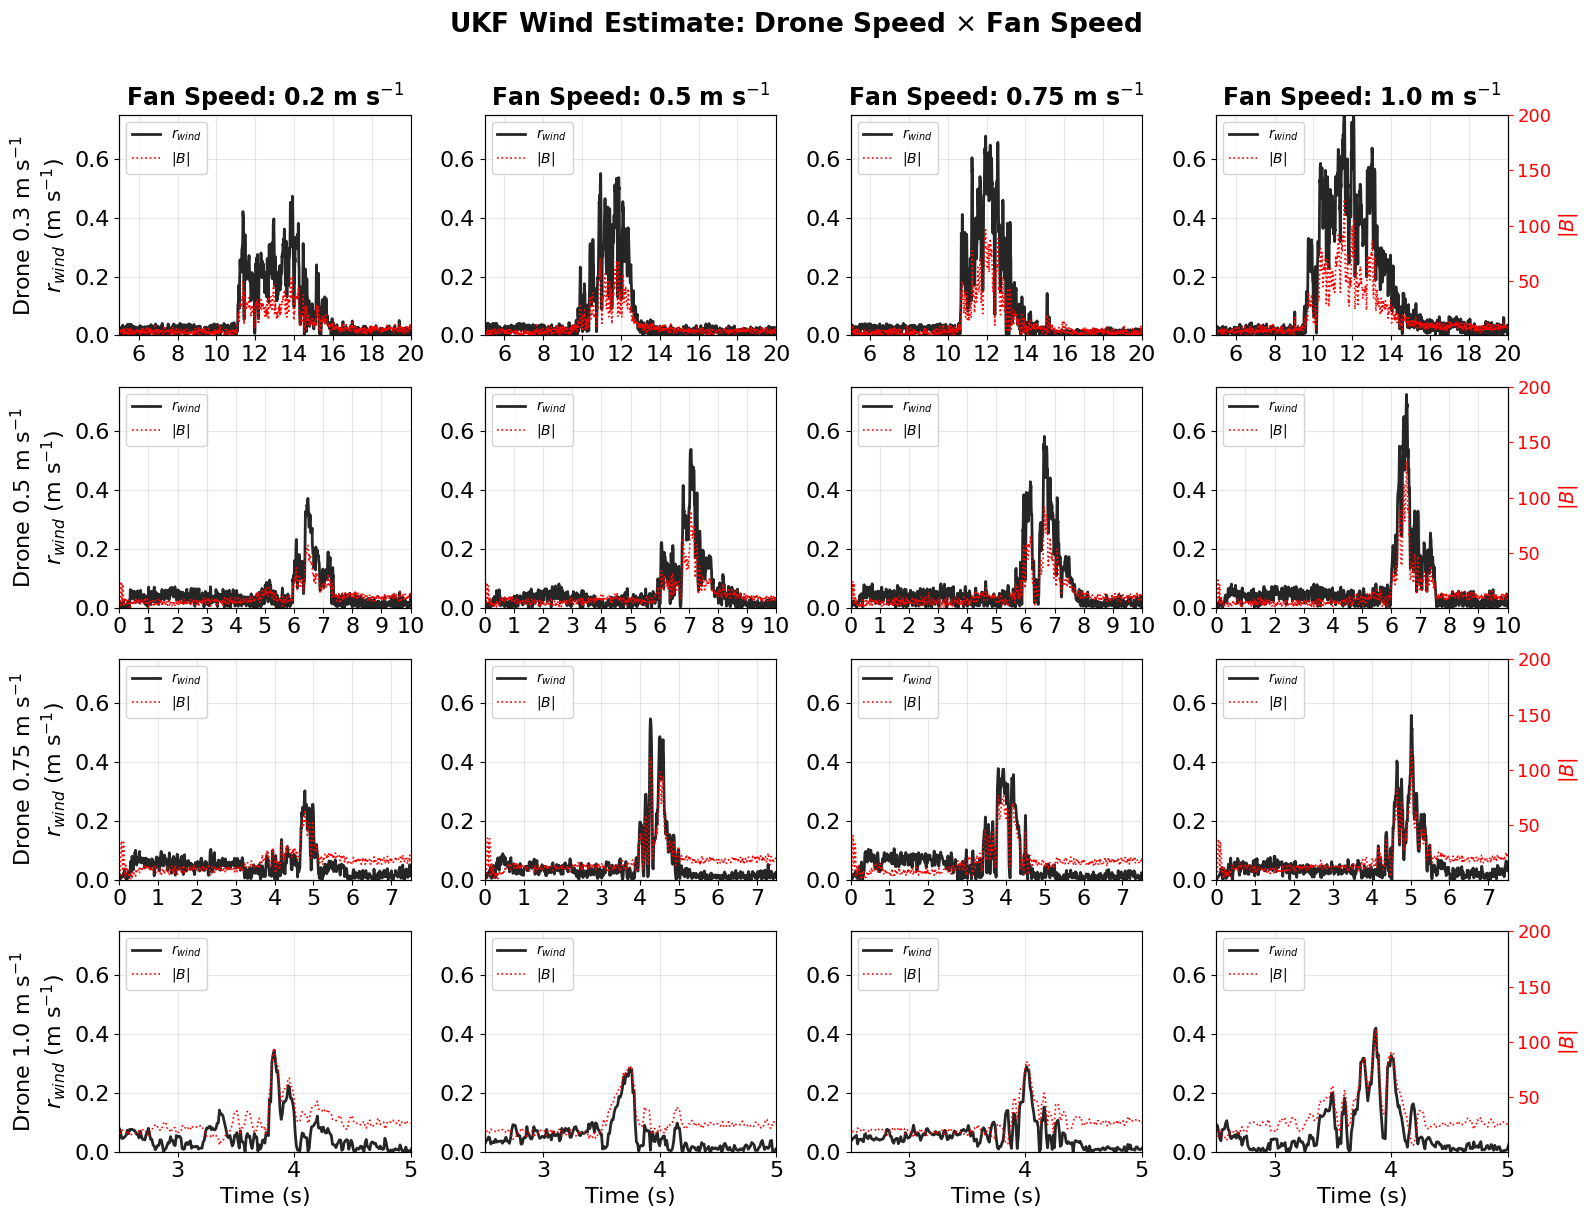

In [29]:
"""
UKF Wind Estimation Sensitivity Analysis
Grid Layout: rows = drone speeds, cols = fan speeds
Each cell shows wind_mag time series for that (drone, fan) combo.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter
import liveWindUKF
import importlib
import liveWindUKF
importlib.reload(liveWindUKF)

# =============================================================================
# Data Loading
# =============================================================================

def moving_average_filter(data, window_size):
    b = np.ones(window_size) / window_size
    a = 1
    return lfilter(b, a, data)


def load_data(filepath):
    df = pd.read_csv(filepath)

    for axis in ['Bx', 'By']:
        df[f'{axis}_filt'] = moving_average_filter(df[axis].values, 10)

    df['Bx_cf'] = df['Bx_filt']
    df['By_cf'] = df['By_filt']

    df['B_mag']   = np.sqrt(df['Bx_cf'] ** 2 + df['By_cf'] ** 2)
    df['Bxy_mag'] = np.sqrt(df['Bx']    ** 2 + df['By']    ** 2)

    if all(col in df.columns for col in ['Qx', 'Qy', 'Qz']):
        qw_sq    = 1.0 - (df['Qx'] ** 2 + df['Qy'] ** 2 + df['Qz'] ** 2)
        df['qw'] = np.sqrt(np.maximum(qw_sq, 0))

    if 'Vx' in df.columns:
        df['V_mag'] = np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2)

    return df


# =============================================================================
# Run UKF
# =============================================================================

def run_ukf_on_dataset(df):
    liveWindUKF.reset_ukf()

    if 'time' in df.columns:
        time = df['time'].values
        if time[0] > 1000:
            time = time / 1000.0
    else:
        time = np.arange(len(df)) * 0.01

    time = time - time[0]

    N = len(df)
    res = {
        'time':        time,
        'va_mag':      np.zeros(N),
        'wind_mag':    np.zeros(N),
        'v_empirical': np.zeros(N),
        'vx_true':     df['Vx'].values,
        'vy_true':     df['Vy'].values,
        'v_true_mag':  np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2).values,
        'Bx':          df['Bx_cf'].values,
        'By':          df['By_cf'].values,
        'B_mag':       df['FlowMag'].values,
        'Bxy_mag':     df['Bxy_mag'].values,
    }

    for i in range(N):
        B_mag = df['FlowMag'].iloc[i]
        v_mag = np.sqrt(df['Vx'].iloc[i] ** 2 + df['Vy'].iloc[i] ** 2)

        airflow_mag, wind_mag, empirical = liveWindUKF.run_ukf(B_mag, v_mag)

        res['va_mag'][i]      = airflow_mag
        res['wind_mag'][i]    = wind_mag
        res['v_empirical'][i] = empirical

    return res


# =============================================================================
# Plotting
# =============================================================================

from matplotlib.ticker import MaxNLocator

def plot_sensitivity_analysis(results_dict, drone_speeds, fan_speeds,
                               xlims=None, ylims=None, fontsize=20):
    n_rows = len(drone_speeds)
    n_cols = len(fan_speeds)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
    )

    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    color_wind    = 'black'
    color_flowmag = 'red'

    for row_idx, drone_speed in enumerate(drone_speeds):
        for col_idx, fan_speed in enumerate(fan_speeds):
            ax = axes[row_idx, col_idx]

            if (drone_speed in results_dict and
                    fan_speed in results_dict[drone_speed]):

                res      = results_dict[drone_speed][fan_speed]
                mean_val = np.mean(res['wind_mag'])

                l1, = ax.plot(res['time'], res['wind_mag'],
                              color=color_wind, lw=2, alpha=0.85,
                              label=r'$r_{wind}$')
                ax.set_ylim(0, 0.75)

                # Right axis — FlowMag, independent scale per cell
                ax2 = ax.twinx()
                l2, = ax2.plot(res['time'], res['B_mag'],
                               color=color_flowmag, lw=1.2, linestyle=':',
                               label='$|B|$')
                ax2.set_ylim(
                    np.nanmin(res['B_mag']) * 0.95,
                    200
                )

                if col_idx == n_cols - 1:
                    ax2.set_ylabel('$|B|$', fontsize=fontsize - 2, color=color_flowmag)
                    ax2.tick_params(axis='y', labelsize=fontsize - 3, colors=color_flowmag)
                else:
                    ax2.set_yticks([])
                    ax2.spines['right'].set_visible(False)

                # Legend with both lines on each plot
                ax.legend(handles=[l1, l2],
                          loc='upper left',
                          fontsize=fontsize - 6,
                          framealpha=0.85)

            else:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=fontsize, color='gray')

            if xlims and (drone_speed, fan_speed) in xlims:
                ax.set_xlim(xlims[(drone_speed, fan_speed)])
            if ylims and drone_speed in ylims:
                ax.set_ylim(ylims[drone_speed])

            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=fontsize)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))

            if row_idx == 0:
                ax.set_title(f'Fan Speed: {fan_speed} m s$^{{-1}}$',
                             fontsize=fontsize + 1, fontweight='bold')

            if col_idx == 0:
                ax.set_ylabel(
                    f'Drone {drone_speed} m s$^{{-1}}$\n'
                    r'$r_{wind}$ (m s$^{-1}$)',
                    fontsize=fontsize
                )

            if row_idx == n_rows - 1:
                ax.set_xlabel('Time (s)', fontsize=fontsize)

    fig.suptitle(
        r'UKF Wind Estimate: Drone Speed $\times$ Fan Speed',
        fontsize=fontsize + 3, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    return fig


# =============================================================================
# Main
# =============================================================================

def main():
    base_path = r"C:\Users\ltjth\Documents\Research\UKF_Data"

    file_mapping = {
        (0.5,  0.5):  "CF_ARR_Sensitivity_Drone0.5_Fan0.51.csv",
        (2.0,  0.5):  "testCharacerization2.0drone_0.5fan_ortho1.csv",
        (0.75, 0.5):  "CF_ARR_Sensitivity_Drone0.75_Fan0.51.csv",
        (1.0,  0.5):  "CF_ARR_Sensitivity_Drone1.0_Fan0.51.csv",
        (0.3,  1.0):  "CF_ARR_Sensitivity_Drone0.3_Fan1.01.csv",
        (0.3,  0.2):  "CF_ARR_Sensitivity_Drone0.3_Fan0.21.csv",
        (0.5,  0.2):  "CF_ARR_Sensitivity_Drone0.5_Fan0.21.csv",
        (0.75, 0.2):  "CF_ARR_Sensitivity_Drone0.75_Fan0.21.csv",
        (1.0,  0.2):  "CF_ARR_Sensitivity_Drone1.0_Fan0.21.csv",
        (0.3,  0.5):  "CF_ARR_Sensitivity_Drone0.3_Fan0.51.csv",
        (0.3,  0.75): "CF_ARR_Sensitivity_Drone0.3_Fan0.751.csv",
        (0.5,  0.75): "CF_ARR_Sensitivity_Drone0.5_Fan0.751.csv",
        (0.75, 0.75): "CF_ARR_Sensitivity_Drone0.75_Fan0.751.csv",
        (1.0,  0.75): "CF_ARR_Sensitivity_Drone1.0_Fan0.751.csv",
        (0.5,  1.0):  "CF_ARR_Sensitivity_Drone0.5_Fan1.01.csv",
        (0.75, 1.0):  "CF_ARR_Sensitivity_Drone0.75_Fan1.01.csv",
        (1.0,  1.0):  "CF_ARR_Sensitivity_Drone1.0_Fan1.01.csv",
    }

    drone_speeds = [0.3, 0.5, 0.75, 1.0]
    fan_speeds   = [0.2, 0.5, 0.75, 1.0]

    xlims = {
        (0.3,  0.2):  (5, 20),
        (0.3,  0.5):  (5, 20),
        (0.3,  0.75): (5, 20),
        (0.3,  1.0):  (5, 20),
        (0.5,  0.2):  (0, 10),
        (0.5,  0.5):  (0, 10),
        (0.5,  0.75): (0, 10),
        (0.5,  1.0):  (0, 10),
        (0.75, 0.2):  (0, 7.5),
        (0.75, 0.5):  (0, 7.5),
        (0.75, 0.75): (0, 7.5),
        (0.75, 1.0):  (0, 7.5),
        (1.0,  0.2):  (2.5, 5),
        (1.0,  0.5):  (2.5, 5),
        (1.0,  0.75): (2.5, 5),
        (1.0,  1.0):  (2.5, 5),
    }

    print("=" * 60)
    print("UKF SENSITIVITY ANALYSIS: Drone Speed × Fan Speed")
    print("Using liveWindUKF module")
    print("=" * 60)

    results_dict = {}

    for drone_speed in drone_speeds:
        print(f"\n--- Drone Speed: {drone_speed} m/s ---")
        results_dict[drone_speed] = {}

        for fan_speed in fan_speeds:
            if (drone_speed, fan_speed) not in file_mapping:
                print(f"  Fan {fan_speed} m/s: no file mapped — will show 'No Data'")
                continue

            filepath = f"{base_path}\\{file_mapping[(drone_speed, fan_speed)]}"
            print(f"  Fan {fan_speed} m/s: {file_mapping[(drone_speed, fan_speed)]}")

            try:
                df  = load_data(filepath)
                res = run_ukf_on_dataset(df)
                results_dict[drone_speed][fan_speed] = res
                print(f"    → wind: {np.mean(res['wind_mag']):.3f} "
                      f"± {np.std(res['wind_mag']):.3f} m/s")
            except FileNotFoundError:
                print(f"    ✗ File not found: {filepath}")
            except Exception as e:
                print(f"    ✗ Error: {e}")

    print("\nGenerating plot...")
    fig = plot_sensitivity_analysis(
        results_dict, drone_speeds, fan_speeds,
        xlims=xlims,
        fontsize=16
    )

    # fig.savefig('ukf_sensitivity_grid.pdf', dpi=300, bbox_inches='tight')
    # fig.savefig('ukf_sensitivity_grid.png', dpi=300, bbox_inches='tight')

    plt.show()


if __name__ == "__main__":
    main()

  Drone 0.3 m/s: CF_ARR_Sensitivity_Drone0.3_Fan0.21.csv
    → wind: 0.047 ± 0.096 m/s
  Drone 0.5 m/s: CF_ARR_Sensitivity_Drone0.5_Fan0.21.csv
    → wind: 0.033 ± 0.057 m/s
  Drone 0.75 m/s: CF_ARR_Sensitivity_Drone0.75_Fan0.21.csv
    → wind: 0.045 ± 0.070 m/s
  Drone 1.0 m/s: CF_ARR_Sensitivity_Drone1.0_Fan0.21.csv
    → wind: 0.033 ± 0.060 m/s

Generating plot...


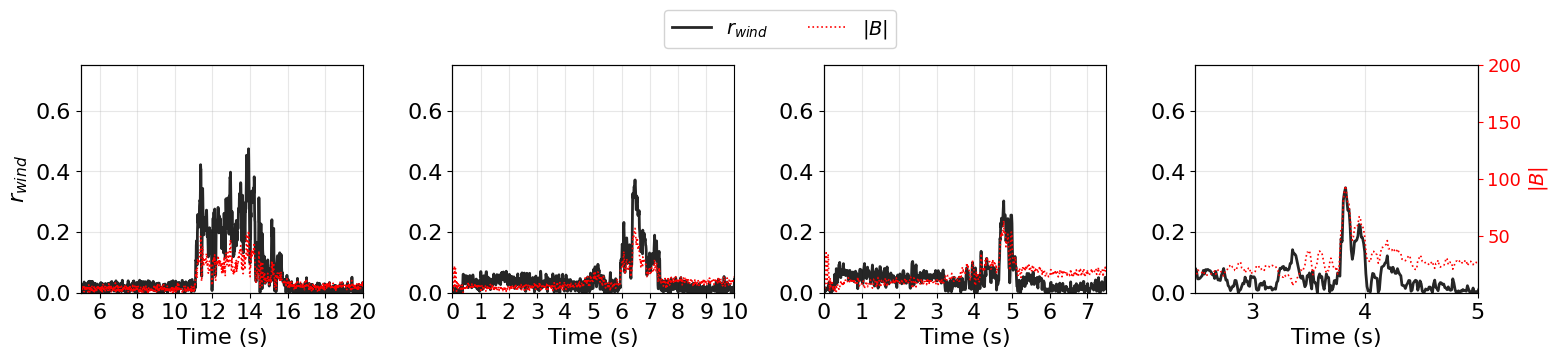

In [13]:
"""
UKF Wind Estimation Sensitivity Analysis
Fan Speed 0.2 m/s only — 1x4 layout, drone speeds increasing left to right.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter
import liveWindUKF
import importlib
importlib.reload(liveWindUKF)

# =============================================================================
# Data Loading
# =============================================================================

def moving_average_filter(data, window_size):
    b = np.ones(window_size) / window_size
    a = 1
    return lfilter(b, a, data)


def load_data(filepath):
    df = pd.read_csv(filepath)

    for axis in ['Bx', 'By']:
        df[f'{axis}_filt'] = moving_average_filter(df[axis].values, 10)

    df['Bx_cf'] = df['Bx_filt']
    df['By_cf'] = df['By_filt']

    df['B_mag']   = np.sqrt(df['Bx_cf'] ** 2 + df['By_cf'] ** 2)
    df['Bxy_mag'] = np.sqrt(df['Bx']    ** 2 + df['By']    ** 2)

    if all(col in df.columns for col in ['Qx', 'Qy', 'Qz']):
        qw_sq    = 1.0 - (df['Qx'] ** 2 + df['Qy'] ** 2 + df['Qz'] ** 2)
        df['qw'] = np.sqrt(np.maximum(qw_sq, 0))

    if 'Vx' in df.columns:
        df['V_mag'] = np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2)

    return df


# =============================================================================
# Run UKF
# =============================================================================

def run_ukf_on_dataset(df):
    liveWindUKF.reset_ukf()

    if 'time' in df.columns:
        time = df['time'].values
        if time[0] > 1000:
            time = time / 1000.0
    else:
        time = np.arange(len(df)) * 0.01

    time = time - time[0]

    N = len(df)
    res = {
        'time':        time,
        'va_mag':      np.zeros(N),
        'wind_mag':    np.zeros(N),
        'v_empirical': np.zeros(N),
        'vx_true':     df['Vx'].values,
        'vy_true':     df['Vy'].values,
        'v_true_mag':  np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2).values,
        'Bx':          df['Bx_cf'].values,
        'By':          df['By_cf'].values,
        'B_mag':       df['FlowMag'].values,
        'Bxy_mag':     df['Bxy_mag'].values,
    }

    for i in range(N):
        B_mag = df['FlowMag'].iloc[i]
        v_mag = np.sqrt(df['Vx'].iloc[i] ** 2 + df['Vy'].iloc[i] ** 2)

        airflow_mag, wind_mag, empirical = liveWindUKF.run_ukf(B_mag, v_mag)

        res['va_mag'][i]      = airflow_mag
        res['wind_mag'][i]    = wind_mag
        res['v_empirical'][i] = empirical

    return res


# =============================================================================
# Plotting — 1x4, fan speed 0.2 only
# =============================================================================

from matplotlib.ticker import MaxNLocator

def plot_fan02_row(results_dict, drone_speeds, fan_speed,
                  xlims=None, fontsize=16):
    n_cols = len(drone_speeds)

    fig, axes = plt.subplots(
        1, n_cols,
        figsize=(4 * n_cols, 3.5),
    )

    color_wind    = 'black'
    color_flowmag = 'red'
    legend_handles = []

    for col_idx, drone_speed in enumerate(drone_speeds):
        ax = axes[col_idx]

        if (drone_speed in results_dict and
                fan_speed in results_dict[drone_speed]):

            res = results_dict[drone_speed][fan_speed]

            l1, = ax.plot(res['time'], res['wind_mag'],
                          color=color_wind, lw=2, alpha=0.85,
                          label=r'$r_{wind}$')
            ax.set_ylim(0, 0.75)

            # Right axis — FlowMag
            ax2 = ax.twinx()
            l2, = ax2.plot(res['time'], res['B_mag'],
                           color=color_flowmag, lw=1.2, linestyle=':',
                           label='$|B|$')
            ax2.set_ylim(
                np.nanmin(res['B_mag']) * 0.95,
                200
            )

            if col_idx == n_cols - 1:
                ax2.set_ylabel('$|B|$', fontsize=fontsize - 2, color=color_flowmag)
                ax2.tick_params(axis='y', labelsize=fontsize - 3, colors=color_flowmag)
            else:
                ax2.set_yticks([])
                ax2.spines['right'].set_visible(False)

            # Collect legend handles from first cell only
            if col_idx == 0:
                legend_handles = [l1, l2]

        else:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=fontsize, color='gray')

        # Apply xlims
        if xlims and (drone_speed, fan_speed) in xlims:
            ax.set_xlim(xlims[(drone_speed, fan_speed)])

        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=fontsize)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        # ax.set_title(f'Drone Speed: {drone_speed} m s$^{{-1}}$',
        #              fontsize=fontsize + 1, fontweight='bold')

        ax.set_xlabel('Time (s)', fontsize=fontsize)

        if col_idx == 0:
            ax.set_ylabel(r'$r_{wind}$', fontsize=fontsize)

    # fig.suptitle(
    #     f'UKF Wind Estimate: Fan Speed {fan_speed} m s$^{{-1}}$',
    #     fontsize=fontsize + 3, fontweight='bold', y=1.03
    # )
    plt.tight_layout()

    # Single shared legend above the plots
    fig.legend(handles=legend_handles,
               loc='upper center',
               bbox_to_anchor=(0.5, 1.08),
               ncol=2,
               fontsize=fontsize - 2,
               framealpha=0.85)

    return fig


# =============================================================================
# Main
# =============================================================================

def main():
    base_path = r"C:\Users\ltjth\Documents\Research\UKF_Data"

    file_mapping = {
        (0.3,  0.2): "CF_ARR_Sensitivity_Drone0.3_Fan0.21.csv",
        (0.5,  0.2): "CF_ARR_Sensitivity_Drone0.5_Fan0.21.csv",
        (0.75, 0.2): "CF_ARR_Sensitivity_Drone0.75_Fan0.21.csv",
        (1.0,  0.2): "CF_ARR_Sensitivity_Drone1.0_Fan0.21.csv",
    }

    drone_speeds = [0.3, 0.5, 0.75, 1.0]
    fan_speed    = 0.2

    xlims = {
        (0.3,  0.2): (5,   20),
        (0.5,  0.2): (0,   10),
        (0.75, 0.2): (0,   7.5),
        (1.0,  0.2): (2.5, 5),
    }

    print("=" * 60)
    #print("UKF SENSITIVITY ANALYSIS: Fan Speed 0.2 m/s")
    print("=" * 60)

    results_dict = {}

    for drone_speed in drone_speeds:
        results_dict[drone_speed] = {}
        key = (drone_speed, fan_speed)

        if key not in file_mapping:
            print(f"  Drone {drone_speed} m/s: no file mapped — will show 'No Data'")
            continue

        filepath = f"{base_path}\\{file_mapping[key]}"
        print(f"  Drone {drone_speed} m/s: {file_mapping[key]}")

        try:
            df  = load_data(filepath)
            res = run_ukf_on_dataset(df)
            results_dict[drone_speed][fan_speed] = res
            print(f"    → wind: {np.mean(res['wind_mag']):.3f} "
                  f"± {np.std(res['wind_mag']):.3f} m/s")
        except FileNotFoundError:
            print(f"    ✗ File not found: {filepath}")
        except Exception as e:
            print(f"    ✗ Error: {e}")

    print("\nGenerating plot...")
    fig = plot_fan02_row(
        results_dict, drone_speeds, fan_speed,
        xlims=xlims,
        fontsize=16
    )

    # fig.savefig('ukf_sensitivity_fan0.2.pdf', dpi=300, bbox_inches='tight')
    # fig.savefig('ukf_sensitivity_fan0.2.png', dpi=300, bbox_inches='tight')

    plt.show()


if __name__ == "__main__":
    main()

UKF SENSITIVITY ANALYSIS: Drone Speed × Fan Speed
Using liveWindUKF module

--- Drone Speed: 0.3 m/s ---
  Fan 0.2 m/s: CF_ARR_Sensitivity_Drone0.3_Fan0.21.csv
    → wind: 0.047 ± 0.096 m/s
  Fan 0.5 m/s: CF_ARR_Sensitivity_Drone0.3_Fan0.51.csv
    → wind: 0.042 ± 0.085 m/s
  Fan 0.75 m/s: CF_ARR_Sensitivity_Drone0.3_Fan0.751.csv
    → wind: 0.051 ± 0.112 m/s
  Fan 1.0 m/s: CF_ARR_Sensitivity_Drone0.3_Fan1.01.csv
    → wind: 0.073 ± 0.143 m/s

--- Drone Speed: 0.5 m/s ---
  Fan 0.2 m/s: CF_ARR_Sensitivity_Drone0.5_Fan0.21.csv
    → wind: 0.033 ± 0.057 m/s
  Fan 0.5 m/s: CF_ARR_Sensitivity_Drone0.5_Fan0.51.csv
    → wind: 0.072 ± 0.107 m/s
  Fan 0.75 m/s: CF_ARR_Sensitivity_Drone0.5_Fan0.751.csv
    → wind: 0.036 ± 0.071 m/s
  Fan 1.0 m/s: CF_ARR_Sensitivity_Drone0.5_Fan1.01.csv
    → wind: 0.036 ± 0.075 m/s

--- Drone Speed: 0.75 m/s ---
  Fan 0.2 m/s: CF_ARR_Sensitivity_Drone0.75_Fan0.21.csv
    → wind: 0.045 ± 0.070 m/s
  Fan 0.5 m/s: CF_ARR_Sensitivity_Drone0.75_Fan0.51.csv
    → wi

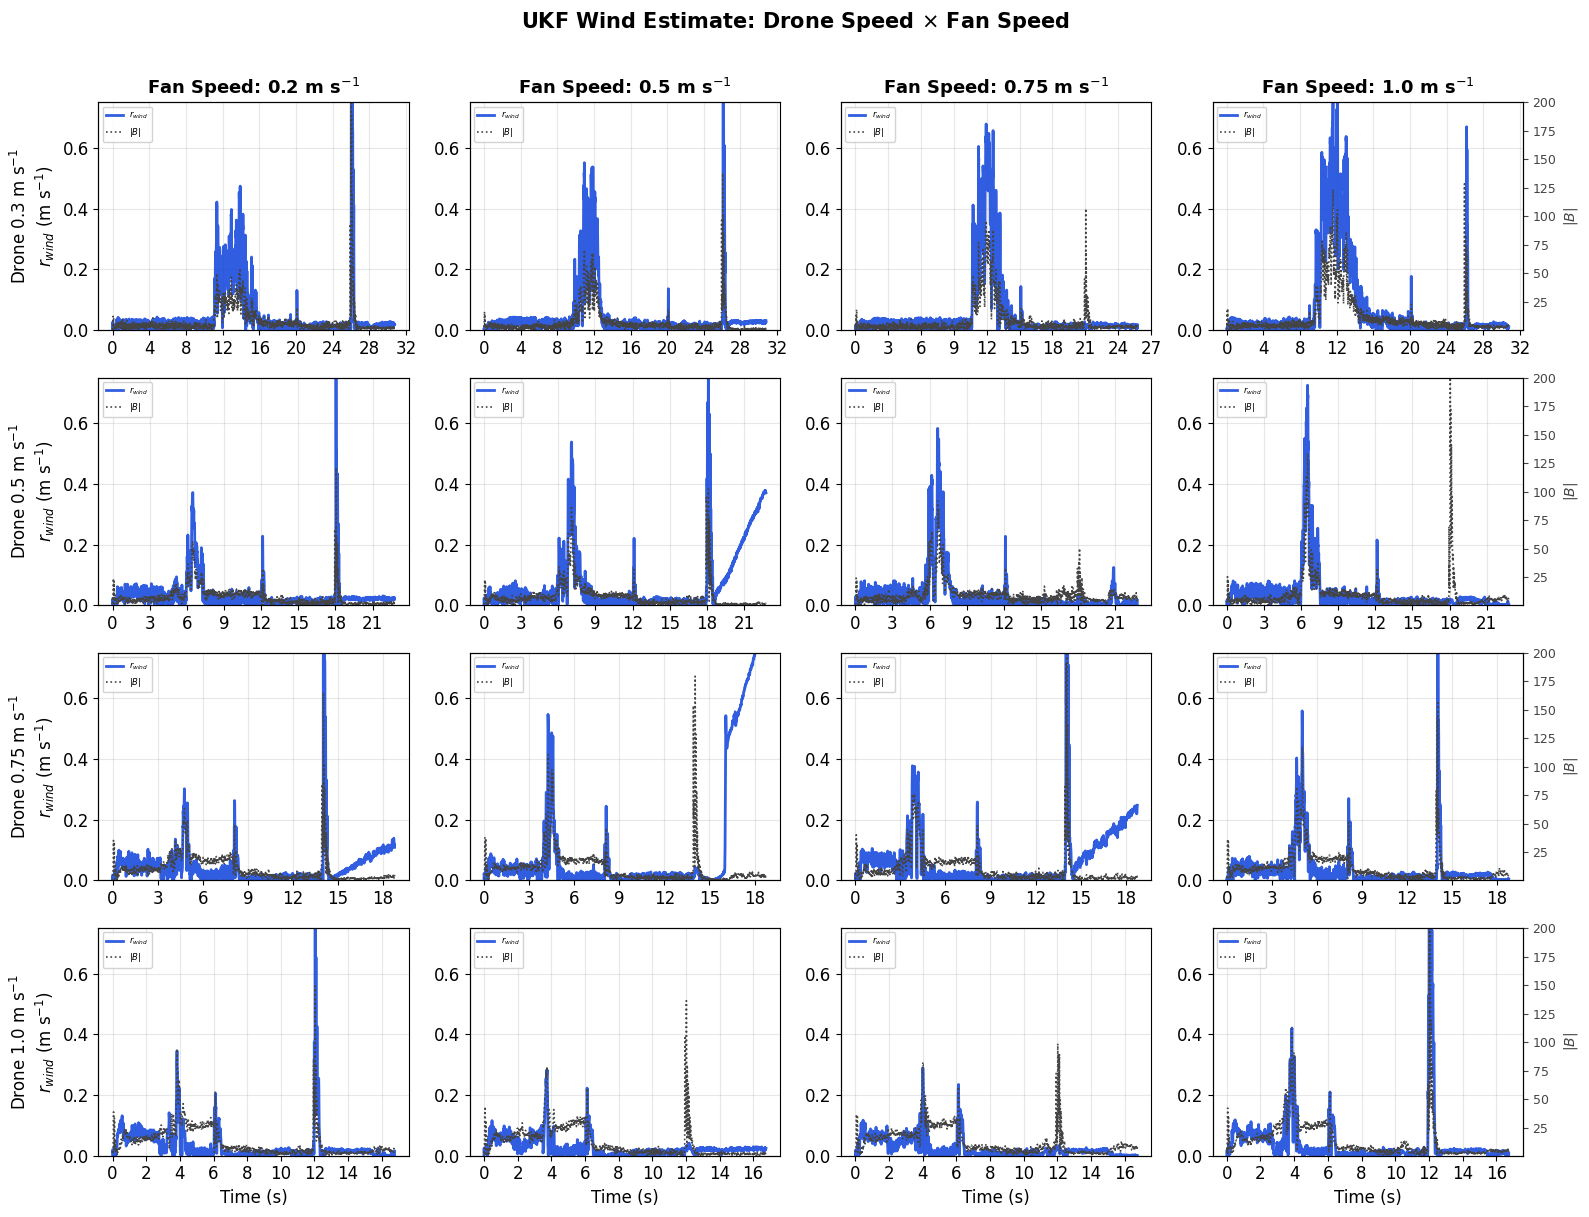

In [24]:
"""
UKF Wind Estimation Sensitivity Analysis
Grid Layout: rows = drone speeds, cols = fan speeds
Each cell shows wind_mag time series for that (drone, fan) combo.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter
import liveWindUKF
import importlib
import liveWindUKF
importlib.reload(liveWindUKF)

# =============================================================================
# Data Loading
# =============================================================================

def moving_average_filter(data, window_size):
    b = np.ones(window_size) / window_size
    a = 1
    return lfilter(b, a, data)


def load_data(filepath):
    df = pd.read_csv(filepath)

    for axis in ['Bx', 'By']:
        df[f'{axis}_filt'] = moving_average_filter(df[axis].values, 10)

    df['Bx_cf'] = df['Bx_filt']
    df['By_cf'] = df['By_filt']

    df['B_mag']   = np.sqrt(df['Bx_cf'] ** 2 + df['By_cf'] ** 2)
    df['Bxy_mag'] = np.sqrt(df['Bx']    ** 2 + df['By']    ** 2)

    if all(col in df.columns for col in ['Qx', 'Qy', 'Qz']):
        qw_sq    = 1.0 - (df['Qx'] ** 2 + df['Qy'] ** 2 + df['Qz'] ** 2)
        df['qw'] = np.sqrt(np.maximum(qw_sq, 0))

    if 'Vx' in df.columns:
        df['V_mag'] = np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2)

    return df


# =============================================================================
# Run UKF
# =============================================================================

def run_ukf_on_dataset(df):
    liveWindUKF.reset_ukf()

    if 'time' in df.columns:
        time = df['time'].values
        if time[0] > 1000:
            time = time / 1000.0
    else:
        time = np.arange(len(df)) * 0.01

    time = time - time[0]

    N = len(df)
    res = {
        'time':        time,
        'va_mag':      np.zeros(N),
        'wind_mag':    np.zeros(N),
        'v_empirical': np.zeros(N),
        'vx_true':     df['Vx'].values,
        'vy_true':     df['Vy'].values,
        'v_true_mag':  np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2).values,
        'Bx':          df['Bx_cf'].values,
        'By':          df['By_cf'].values,
        'B_mag':       df['FlowMag'].values,
        'Bxy_mag':     df['Bxy_mag'].values,
    }

    for i in range(N):
        B_mag = df['FlowMag'].iloc[i]
        v_mag = np.sqrt(df['Vx'].iloc[i] ** 2 + df['Vy'].iloc[i] ** 2)

        airflow_mag, wind_mag, empirical = liveWindUKF.run_ukf(B_mag, v_mag)

        res['va_mag'][i]      = airflow_mag
        res['wind_mag'][i]    = wind_mag
        res['v_empirical'][i] = empirical

    return res


# =============================================================================
# Plotting
# =============================================================================

def plot_sensitivity_analysis(results_dict, drone_speeds, fan_speeds,
                               xlims=None, ylims=None, fontsize=12):
    n_rows = len(drone_speeds)
    n_cols = len(fan_speeds)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
    )

    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    color_wind    = '#000000'
    color_flowmag = '#888888'

    for row_idx, drone_speed in enumerate(drone_speeds):
        for col_idx, fan_speed in enumerate(fan_speeds):
            ax = axes[row_idx, col_idx]

            if (drone_speed in results_dict and
                    fan_speed in results_dict[drone_speed]):

                res      = results_dict[drone_speed][fan_speed]
                mean_val = np.mean(res['wind_mag'])

                ax.plot(res['time'], res['va_mag'],
                        color=color_wind, lw=2, alpha=0.85)
                ax.plot(res['time'], res['v_true_mag'], lw=2, alpha=0.85)
                # ax.set_ylim(0,0.5)
                ax.legend(loc='upper left', fontsize=fontsize - 3, framealpha=0.85)

                # Right axis — FlowMag, independent scale per cell
                ax2 = ax.twinx()
                ax2.plot(res['time'], res['B_mag'],
                         color=color_flowmag, lw=1.2, linestyle=':')
                ax2.set_ylim(
                    np.nanmin(res['B_mag']) * 0.95,
                   200
                )

                if col_idx == n_cols - 1:
                    ax2.set_ylabel('$|B|$', fontsize=fontsize - 2, color=color_flowmag)
                    ax2.tick_params(axis='y', labelsize=fontsize - 3, colors=color_flowmag)
                else:
                    ax2.set_yticks([])
                    ax2.spines['right'].set_visible(False)

            else:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=fontsize, color='gray')

            if xlims and (drone_speed, fan_speed) in xlims:
                ax.set_xlim(xlims[(drone_speed, fan_speed)])
            if ylims and drone_speed in ylims:
                ax.set_ylim(ylims[drone_speed])

            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=fontsize - 2)

            if row_idx == 0:
                ax.set_title(f'Fan Speed: {fan_speed} m s$^{{-1}}$',
                             fontsize=fontsize + 1, fontweight='bold')

            if col_idx == 0:
                ax.set_ylabel(
                    f'Drone {drone_speed} m s$^{{-1}}$\n'
                    r'$r_{wind}$ (m s$^{-1}$)',
                    fontsize=fontsize
                )

            if row_idx == n_rows - 1:
                ax.set_xlabel('Time (s)', fontsize=fontsize)

    fig.suptitle(
        r'UKF Wind Estimate: Drone Speed $\times$ Fan Speed',
        fontsize=fontsize + 3, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    return fig


# =============================================================================
# Main
# =============================================================================

def main():
    base_path = r"C:\Users\ltjth\Documents\Research\UKF_Data"

    file_mapping = {
        (0.5,  0.5):  "CF_ARR_Sensitivity_Drone0.5_Fan0.51.csv",
        (2.0,  0.5):  "testCharacerization2.0drone_0.5fan_ortho1.csv",
        (0.75, 0.5):  "CF_ARR_Sensitivity_Drone0.75_Fan0.51.csv",
        (1.0,  0.5):  "CF_ARR_Sensitivity_Drone1.0_Fan0.51.csv",
        (0.3,  1.0):  "CF_ARR_Sensitivity_Drone0.3_Fan1.01.csv",
        (0.3,  0.2):  "CF_ARR_Sensitivity_Drone0.3_Fan0.21.csv",
        (0.5,  0.2):  "CF_ARR_Sensitivity_Drone0.5_Fan0.21.csv",
        (0.75, 0.2):  "CF_ARR_Sensitivity_Drone0.75_Fan0.21.csv",
        (1.0,  0.2):  "CF_ARR_Sensitivity_Drone1.0_Fan0.21.csv",
        (0.3,  0.5):  "CF_ARR_Sensitivity_Drone0.3_Fan0.51.csv",
        (0.3,  0.75): "CF_ARR_Sensitivity_Drone0.3_Fan0.751.csv",
        (0.5,  0.75): "CF_ARR_Sensitivity_Drone0.5_Fan0.751.csv",
        (0.75, 0.75): "CF_ARR_Sensitivity_Drone0.75_Fan0.751.csv",
        (1.0,  0.75): "CF_ARR_Sensitivity_Drone1.0_Fan0.751.csv",
        (0.5,  1.0):  "CF_ARR_Sensitivity_Drone0.5_Fan1.01.csv",
        (0.75, 1.0):  "CF_ARR_Sensitivity_Drone0.75_Fan1.01.csv",
        (1.0,  1.0):  "CF_ARR_Sensitivity_Drone1.0_Fan1.01.csv",
    }

    drone_speeds = [0.3, 0.5, 0.75, 1.0]
    fan_speeds   = [0.2, 0.5, 0.75, 1.0]

    xlims = {
        (0.3,  0.2):  (5, 20),
        (0.3,  0.5):  (5, 20),
        (0.3,  0.75): (5, 20),
        (0.3,  1.0):  (5, 20),
        (0.5,  0.2):  (0, 10),
        (0.5,  0.5):  (0, 10),
        (0.5,  0.75): (0, 10),
        (0.5,  1.0):  (0, 10),
        (0.75, 0.2):  (0, 7.5),
        (0.75, 0.5):  (0, 7.5),
        (0.75, 0.75): (0, 7.5),
        (0.75, 1.0):  (0, 7.5),
        (1.0,  0.2):  (0, 15),
        (1.0,  0.5):  (0, 15),
        (1.0,  0.75): (0, 15),
        (1.0,  1.0):  (0, 15),
    }

    print("=" * 60)
    print("UKF SENSITIVITY ANALYSIS: Drone Speed × Fan Speed")
    print("Using liveWindUKF module")
    print("=" * 60)

    results_dict = {}

    for drone_speed in drone_speeds:
        print(f"\n--- Drone Speed: {drone_speed} m/s ---")
        results_dict[drone_speed] = {}

        for fan_speed in fan_speeds:
            if (drone_speed, fan_speed) not in file_mapping:
                print(f"  Fan {fan_speed} m/s: no file mapped — will show 'No Data'")
                continue

            filepath = f"{base_path}\\{file_mapping[(drone_speed, fan_speed)]}"
            print(f"  Fan {fan_speed} m/s: {file_mapping[(drone_speed, fan_speed)]}")

            try:
                df  = load_data(filepath)
                res = run_ukf_on_dataset(df)
                results_dict[drone_speed][fan_speed] = res
                print(f"    → wind: {np.mean(res['wind_mag']):.3f} "
                      f"± {np.std(res['wind_mag']):.3f} m/s")
            except FileNotFoundError:
                print(f"    ✗ File not found: {filepath}")
            except Exception as e:
                print(f"    ✗ Error: {e}")

    print("\nGenerating plot...")
    fig = plot_sensitivity_analysis(
        results_dict, drone_speeds, fan_speeds,
        xlims=None,
        fontsize=12
    )

    # fig.savefig('ukf_sensitivity_grid.pdf', dpi=300, bbox_inches='tight')
    # fig.savefig('ukf_sensitivity_grid.png', dpi=300, bbox_inches='tight')

    plt.show()


if __name__ == "__main__":
    main()